---
# Traffic Sign Detection with YOLOv8 - E1402 Final Project

## Student Information
- **Name:** Duong Binh An
- **Student Code:** MSc-IA-25-0003304EN
- **Subject:** E1402 Digital and Computer Vision
- **Supervisor:** UMEF (Université Mention E1402)
- **Academic Year:** 2025

---

## Project Scope

**Active Pipeline (Main Focus):**
- **Traffic Sign Detection** using YOLOv8 (GTSRB dataset, 43 classes)
- Full EDA, data validation, train/val/test split
- Model training, evaluation, comparison (n/s/m variants)
- Performance metrics and visualization
- Inference on images/folders/video
- GPU training support with conda environment

**Legacy Sections (Reference Only):**
- Sign classifier (ResNet CNN) - archived for reference
- Traffic violation detection logic - out of current scope
- Vehicle tracking and multi-object tracking - archived


---

## Quick Start Guide

**Run sections in this order for complete YOLO Detection pipeline:**

1. **SECTION 1** - Environment Setup (imports & paths)
2. **SECTION 2** - Data Loading & Validation  
3. **SECTION 3** - EDA & Analysis
4. **SECTION 4** - Data Preparation (split & export)
5. **SECTION 5** - Model Training
6. **SECTION 6** - Evaluation & Metrics
7. **SECTION 7** - Model Comparison (optional, set `RUN_MODEL_COMPARISON=True`)
8. **SECTION 8** - Hyperparameter Optimization (optional, set `RUN_OPTIMIZATION=True`)
9. **SECTION 9** - Inference
10. **SECTION 10** - Final Summary

**Legacy Sections** (reference only, skipped by default):
- Sign Classifier (CNN/ResNet) - Archived
- Violation Detection - Out of scope
- Advanced ML Experiments - Reference

In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s eta 0:00:00


In [3]:
pip install kagglehub

In [4]:
# ============================================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================================
# Set up imports, random seeds, project paths, and verify data availability

import os
import cv2
import json # type: ignore
import random
import time
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models # type: ignore
from PIL import Image

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from ultralytics import YOLO # type: ignore

# ============================================================================
# CONFIGURATION & CONSTANTS
# ============================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # type: ignore

# Dataset and model configuration
INPUT_SIZE = 32
NUM_SIGN_CLASSES = 43
BATCH_SIZE = 32
EPOCHS = 10
LR = 0.001

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================================================================
# PROJECT PATHS
# ============================================================================
ROOT_DIR = Path("/content/") # Changed from Windows path to Colab-compatible path
# DATA_ROOT will be set by kagglehub.dataset_download later
OUTPUT_ROOT = ROOT_DIR / "final-project" / "outputs"
MODEL_ROOT = ROOT_DIR / "final-project" / "models"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

# These data-dependent paths will be defined later after DATA_ROOT is set
# META_CSV
# TRAIN_CSV
# TEST_CSV
# TRAIN_DIR
# TEST_DIR

CLASSIFIER_WEIGHTS = MODEL_ROOT / "gtsrb_sign_classifier_resnet18.pth"
CLASSIFIER_HISTORY = OUTPUT_ROOT / "sign_classifier_history.csv"

# Image extensions
IMG_EXTENSIONS = {'.ppm', '.jpg', '.jpeg', '.png', '.gif', '.bmp'}

# Data root existence checks will be printed later once DATA_ROOT is correctly set

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


In [5]:
import kagglehub

# Download latest version
kaggle_data_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", kaggle_data_path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [6]:
# The Kaggle dataset contains the necessary files directly at the root of the downloaded path.
# So, DATA_ROOT should directly be the path returned by kagglehub.dataset_download.
DATA_ROOT = Path(kaggle_data_path)

In [7]:
# Define data-dependent paths using the correctly set DATA_ROOT
META_CSV = DATA_ROOT / "Meta.csv"
TRAIN_CSV = DATA_ROOT / "Train.csv"
TEST_CSV = DATA_ROOT / "Test.csv"
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR = DATA_ROOT / "Test"

print("Data root exists:", DATA_ROOT.exists())
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Data root exists: True
Train folder exists: True
Test folder exists: True


In [33]:
# ============================================================================
# SECTION 2: DATA LOADING & EXPLORATION
# ============================================================================
# Load metadata and verify dataset structure

# Ensure paths are correctly set before reading
# This re-definition guards against potential stale kernel states
if 'DATA_ROOT' in globals() and DATA_ROOT.exists():
    META_CSV = DATA_ROOT / "Meta.csv"
    TRAIN_CSV = DATA_ROOT / "Train.csv"
    TEST_CSV = DATA_ROOT / "Test.csv"
else:
    raise RuntimeError("DATA_ROOT is not defined or does not exist. Please run previous setup cells.")

meta_df = pd.read_csv(META_CSV)
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Meta shape:", meta_df.shape)
print("Train CSV shape:", train_df.shape)
print("Test CSV shape:", test_df.shape)

candidate_name_cols = ["SignName", "ClassName", "Name", "Description"]
name_col = next((c for c in candidate_name_cols if c in meta_df.columns), None)

class_name_map = {}
if "ClassId" in meta_df.columns:
    for _, row in meta_df.iterrows():
        class_id = int(row["ClassId"])
        if name_col is not None:
            class_name_map[class_id] = str(row[name_col])
        else:
            class_name_map[class_id] = f"class_{class_id}"
else:
    for class_id in sorted(train_df["ClassId"].unique()):
        class_name_map[int(class_id)] = f"class_{int(class_id)}"

def class_id_to_name(class_id: int) -> str:
    class_id = int(class_id)
    return class_name_map.get(class_id, f"class_{class_id}") # type: ignore # type: ignore

print("Number of sign classes:", len(class_name_map)) # type: ignore
print("Example classes:", {k: class_name_map[k] for k in sorted(class_name_map)[:5]}) # type: ignore # type: ignore

Meta shape: (43, 5)
Train CSV shape: (39209, 8)
Test CSV shape: (12630, 8)
Number of sign classes: 43
Example classes: {0: 'class_0', 1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4'}


---

## SECTION 2B (LEGACY): Sign Classifier (CNN/ResNet) - ARCHIVED

> **This section is kept for reference only and is not part of the active YOLO detection pipeline.**
>
> The CNN-based sign classifier was used in earlier experiments. For the final project, use the YOLO detection pipeline (Sections 1-9 above).

---

In [9]:
class GTSRBDataset(Dataset[Tuple[Image.Image, int]]):
    """Custom dataset loader for GTSRB traffic sign recognition dataset."""

    def __init__(self, train_root: Path, transform: Optional[object] = None) -> None:
        self.transform = transform
        self.samples: list[Tuple[Path, int]] = []

        for class_folder in sorted(train_root.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                # Support both .ppm and .png files
                for pattern in ["*.ppm", "*.png", "*.jpg", "*.jpeg"]:
                    for img_file in class_folder.glob(pattern):
                        img_path = img_file.resolve()
                        self.samples.append((img_path, class_idx))
            except ValueError:
                continue

        if len(self.samples) == 0:
            raise ValueError(f"No images found in {train_root}")

        print(f"Loaded {len(self.samples)} images from {train_root}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[Image.Image, int]:
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image) # type: ignore # type: ignore
        return image, label


---

# ACTIVE YOLO DETECTION PIPELINE

> **Run this section for the final Traffic Sign Detection project.**
>
> This is the primary execution path combining data loading, EDA, training, evaluation, and inference for a production-ready YOLO-based traffic sign detection system.

## Overview

**Implemented in Sections 1-9:**

1. **Environment Setup** - Configs, imports, device detection
2. **Data Loading** - GTSRB dataset from CSV files
3. **EDA & Validation** - Class distribution, sample visualization
4. **Data Preparation** - Stratified split, YOLO format conversion
5. **Training** - YOLOv8 baseline with GPU support
6. **Evaluation** - Metrics, curves, sample predictions
7. **Model Comparison** - Compare YOLOv8n/s/m variants
8. **Optimization** - Hyperparameter tuning (optional)
9. **Inference** - Run predictions on images/folders/video
10. **Summary** - Final artifacts and reporting

---

In [10]:
@dataclass
class ViolationConfig:
    fps: float = 30.0
    meters_per_pixel: float = 0.05
    speed_limit_kmh: float = 50.0
    stop_speed_threshold_kmh: float = 5.0
    min_wrong_way_pixels: float = 40.0
    expected_direction: str = "down"
    stop_line_y: int = 380
    traffic_light_roi: tuple[int, int, int, int] = (20, 20, 120, 220)
    lane_polygons: list = field(default_factory=list) # type: ignore
    forbidden_zone: list = field(default_factory=list) # type: ignore # type: ignore
    violation_cooldown_frames: int = 30

def bbox_center(x1, y1, x2, y2):
    return int((x1 + x2) / 2), int((y1 + y2) / 2)

def point_in_any_polygon(point, polygons):
    if polygons is None or len(polygons) == 0:
        return True

    x, y = point
    for poly in polygons:
        if cv2.pointPolygonTest(poly, (float(x), float(y)), False) >= 0:
            return True
    return False

class IncidentLogger:
    def __init__(self, output_dir: Path, cooldown_frames: int = 30):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.records = []
        self.last_logged = {}
        self.cooldown_frames = cooldown_frames

    def _should_log(self, track_id, violation_type, frame_idx):
        key = (int(track_id), str(violation_type))
        last = self.last_logged.get(key)
        if last is not None and (frame_idx - last) < self.cooldown_frames:
            return False
        self.last_logged[key] = frame_idx
        return True

    def log(self, frame_bgr, frame_idx, fps, track_id, violation_type, bbox, extra=None):
        if not self._should_log(track_id, violation_type, frame_idx):
            return

        h, w = frame_bgr.shape[:2]
        x1, y1, x2, y2 = clamp_bbox(*bbox, w, h)
        crop = frame_bgr[y1:y2, x1:x2]

        evidence_name = f"frame_{frame_idx:06d}_track_{int(track_id)}_{violation_type.replace(' ', '_')}.jpg"
        evidence_path = self.output_dir / evidence_name
        if crop.size > 0:
            cv2.imwrite(str(evidence_path), crop)

        timestamp = frame_idx / max(1.0, float(fps))
        record = {
            "track_id": int(track_id),
            "frame_idx": int(frame_idx),
            "timestamp_sec": float(timestamp),
            "violation_type": str(violation_type),
            "bbox": [int(x1), int(y1), int(x2), int(y2)],
            "evidence_image": str(evidence_path)
        }

        if extra is not None:
            for k, v in extra.items():
                record[k] = v

        self.records.append(record)

    def to_dataframe(self):
        if len(self.records) == 0:
            return pd.DataFrame(columns=["track_id", "frame_idx", "timestamp_sec", "violation_type", "bbox", "evidence_image"])
        return pd.DataFrame(self.records)

---

## SECTION 2D (LEGACY): Classifier Validation & Testing

> **Legacy classifier evaluation code kept for reference. Not part of active pipeline.**

---

In [11]:
# ============================================================================
# LOAD TRAFFIC SIGN CLASSIFIER MODEL
# ============================================================================
# Create ResNet18 model and load pre-trained weights

print("=" * 70)
print("LOADING SIGN CLASSIFIER MODEL")
print("=" * 70)

try:
    # Create model architecture
    sign_classifier = models.resnet18(weights=None)
    # Modify final layer for 43 traffic sign classes
    sign_classifier.fc = nn.Linear(sign_classifier.fc.in_features, NUM_SIGN_CLASSES)
    sign_classifier = sign_classifier.to(DEVICE)

    # Load checkpoint if it exists
    if CLASSIFIER_WEIGHTS.exists():
        checkpoint = torch.load(CLASSIFIER_WEIGHTS, map_location=DEVICE)
        sign_classifier.load_state_dict(checkpoint)
        print(f"Model loaded from: {CLASSIFIER_WEIGHTS}")
        print(f"Device: {DEVICE}")
        print(f"Model parameters: {sum(p.numel() for p in sign_classifier.parameters()):,}")
    else:
        print(f"WARNING: Model checkpoint not found at {CLASSIFIER_WEIGHTS}")
        print("Model created but not loaded with pre-trained weights")
        print("Will use randomly initialized weights")

    sign_classifier.eval()
    print("Model ready for inference (eval mode)")
    print("=" * 70)

except Exception as e:
    print(f"ERROR loading model: {e}")
    sign_classifier = None
    print("=" * 70)

LOADING SIGN CLASSIFIER MODEL
Model created but not loaded with pre-trained weights
Will use randomly initialized weights
Model ready for inference (eval mode)


Total test images available: 12630
Testing with 12 random images


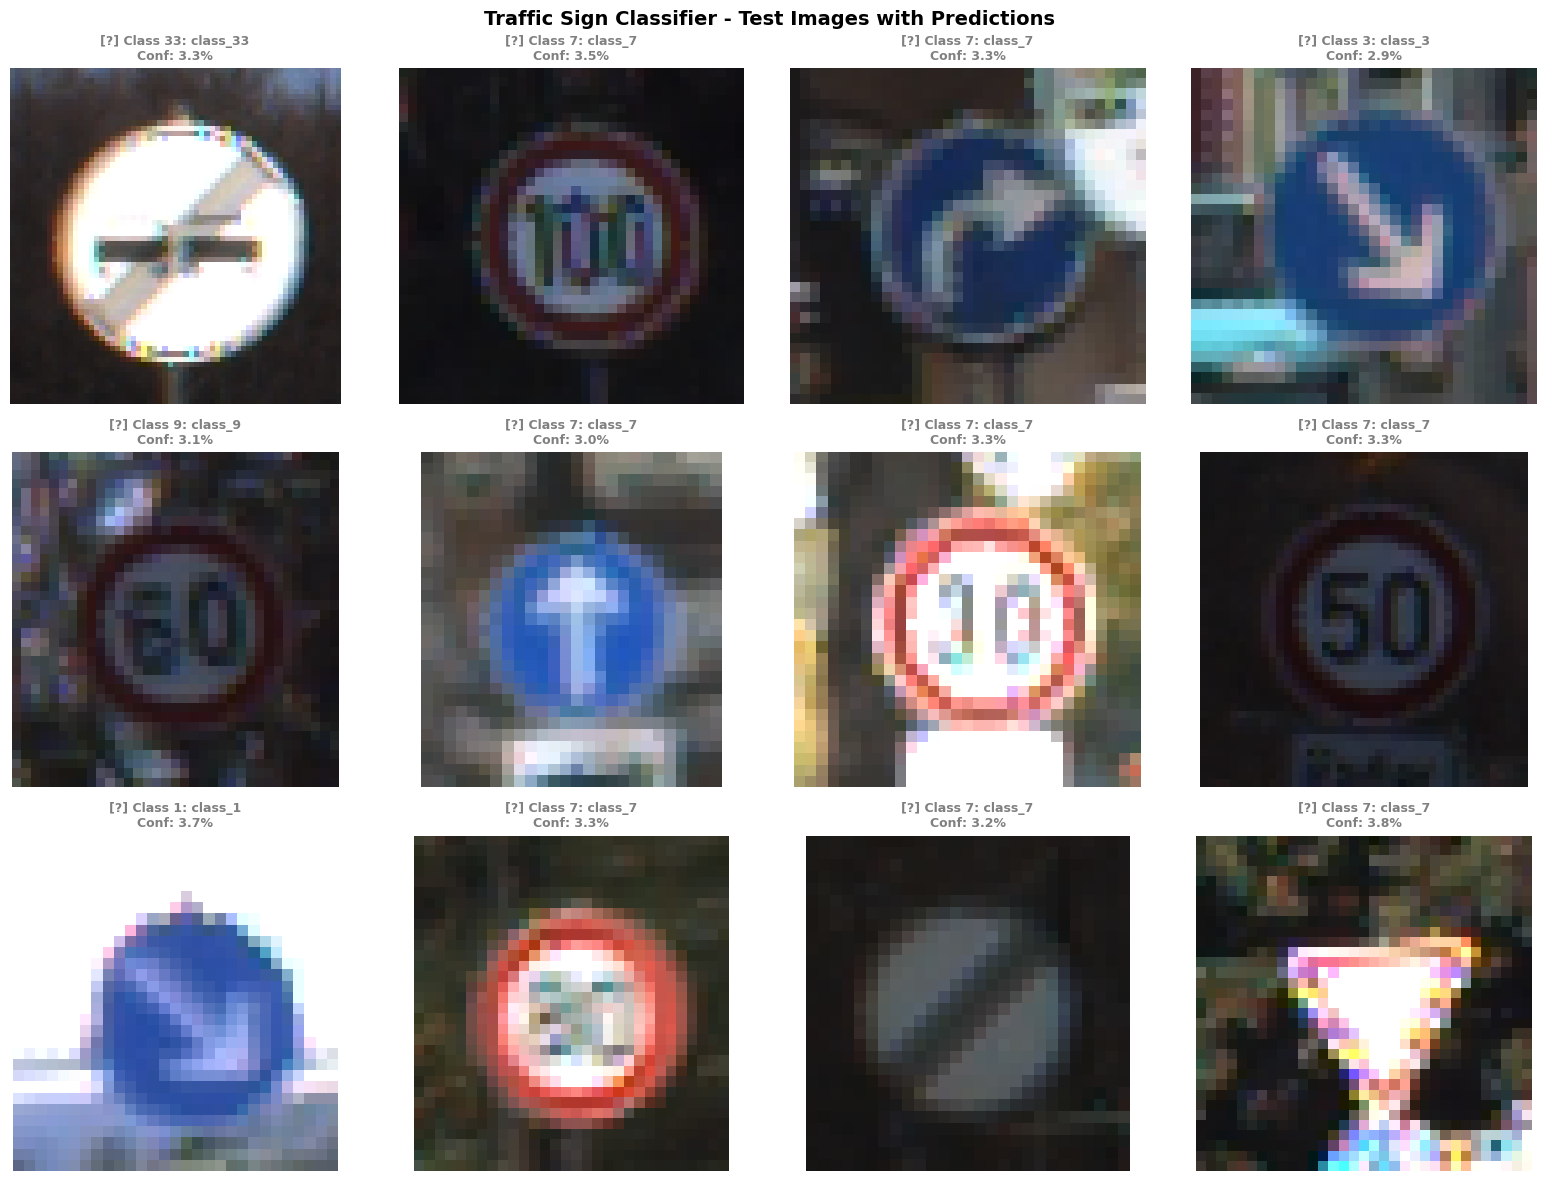


Average Confidence: 3.33%


In [12]:
# ============================================================================
# SECTION 3B: LOAD AND DISPLAY TEST IMAGES WITH PREDICTIONS
# ============================================================================
# Display random test images with model predictions and confidence scores

import torch.nn.functional as F

# Define image transformation pipeline
sign_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Initialize random state
random.seed(SEED)
np.random.seed(SEED)

# Get all test image paths
test_images = []
for img_file in TEST_DIR.glob("*"):
    if img_file.suffix.lower() in IMG_EXTENSIONS and img_file.is_file():
        test_images.append(img_file)

print(f"Total test images available: {len(test_images)}")

# Select random samples
num_samples = 12
if len(test_images) > 0:
    num_to_display = min(num_samples, len(test_images))
    random_indices = random.sample(range(len(test_images)), num_to_display)
    random_test_images = [test_images[i] for i in random_indices]
else:
    random_test_images = []
    print("WARNING: No test images found!")

print(f"Testing with {len(random_test_images)} random images")

# Initialize data collection lists
confidences_list = []
matches = []
correct_predictions = 0
total_predictions = 0

# Create visualization
if len(random_test_images) > 0 and 'sign_classifier' in globals():
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Traffic Sign Classifier - Test Images with Predictions', fontsize=14, fontweight='bold')

    sign_classifier.eval()

    with torch.no_grad():
        for idx, (ax, img_path) in enumerate(zip(axes.flatten(), random_test_images)):
            try:
                # Load and preprocess image
                img = Image.open(img_path).convert('RGB')
                img_tensor = sign_transform(img).unsqueeze(0).to(DEVICE)

                # Get prediction
                output = sign_classifier(img_tensor)
                probabilities = F.softmax(output, dim=1)
                pred_class = output.argmax(dim=1).item()
                confidence = probabilities[0, pred_class].item()
                confidences_list.append(confidence)

                pred_label = class_name_map.get(pred_class, f"Class {pred_class}")

                # Get ground truth from directory name
                try:
                    gt_class = int(img_path.parent.name) if img_path.parent.name.isdigit() else -1
                except:
                    gt_class = -1

                is_correct = (pred_class == gt_class) if gt_class != -1 else None
                if is_correct is not None:
                    correct_predictions += int(is_correct)
                    total_predictions += 1
                    matches.append(is_correct)

                # Display image
                ax.imshow(img)

                # Set title with result indicator
                status = "OK" if is_correct else ("✗" if is_correct is False else "?")
                title = f"[{status}] Class {pred_class}: {pred_label}\nConf: {confidence:.1%}"
                color = 'green' if is_correct else ('red' if is_correct is False else 'gray')

                ax.set_title(title, color=color, fontweight='bold', fontsize=9)
                ax.axis('off')

            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:25]}', ha='center', va='center')
                ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Print summary
    avg_confidence = np.mean(confidences_list) if confidences_list else 0
    print(f"\nAverage Confidence: {avg_confidence:.2%}")
    if total_predictions > 0:
        accuracy = correct_predictions / total_predictions
        print(f"Accuracy on sample: {accuracy:.2%} ({correct_predictions}/{total_predictions})")

else:
    print("Skipping visualization - model not loaded or no test images found")
    confidences_list = []
    matches = []
    avg_confidence = 0

DETAILED MODEL EVALUATION BY TRAFFIC SIGN CLASS
[FAIL] Class  0: class_0                                  | Acc:    0.0% (0/5) | (Total: 60)
[FAIL] Class  1: class_1                                  | Acc:    0.0% (0/5) | (Total: 720)
[FAIL] Class  2: class_2                                  | Acc:    0.0% (0/5) | (Total: 750)
[FAIL] Class  3: class_3                                  | Acc:    0.0% (0/5) | (Total: 450)
[FAIL] Class  4: class_4                                  | Acc:    0.0% (0/5) | (Total: 660)
[FAIL] Class  5: class_5                                  | Acc:    0.0% (0/5) | (Total: 630)
[FAIL] Class  6: class_6                                  | Acc:    0.0% (0/5) | (Total: 150)
[FAIR] Class  7: class_7                                  | Acc:   80.0% (4/5) | (Total: 450)
[FAIL] Class  8: class_8                                  | Acc:    0.0% (0/5) | (Total: 450)
[FAIL] Class  9: class_9                                  | Acc:   20.0% (1/5) | (Total: 480)
[FAIL] Class 

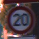

Class 0: class_0 | sample: 00243.png | size: (39, 39)
----------------------------------------------------------------------


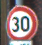

Class 1: class_1 | sample: 00001.png | size: (42, 45)
----------------------------------------------------------------------


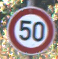

Class 2: class_2 | sample: 00034.png | size: (58, 59)
----------------------------------------------------------------------


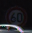

Class 3: class_3 | sample: 00023.png | size: (32, 33)
----------------------------------------------------------------------


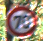

Class 4: class_4 | sample: 00014.png | size: (43, 41)
----------------------------------------------------------------------


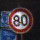

Class 5: class_5 | sample: 00030.png | size: (40, 40)
----------------------------------------------------------------------


Class 6: class_6 | sample: 00129.png | size: (28, 30)
----------------------------------------------------------------------


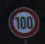

Class 7: class_7 | sample: 00011.png | size: (45, 44)
----------------------------------------------------------------------


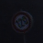

Class 8: class_8 | sample: 00039.png | size: (43, 43)
----------------------------------------------------------------------


Class 9: class_9 | sample: 00015.png | size: (27, 27)
----------------------------------------------------------------------


Class 10: class_10 | sample: 00027.png | size: (28, 29)
----------------------------------------------------------------------


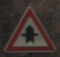

Class 11: class_11 | sample: 00004.png | size: (60, 57)
----------------------------------------------------------------------
Displayed 12 sample image(s).


In [13]:
# Detailed accuracy analysis by traffic sign class with PIL image display
print("=" * 70)
print("DETAILED MODEL EVALUATION BY TRAFFIC SIGN CLASS")
print("=" * 70)

# Collect all test files by class
# NOTE: Test images are stored flat in `Test/` with labels in `Test.csv`.
class_test_files = defaultdict(list)

if 'test_df' not in globals():
    if not TEST_CSV.exists():
        print(f"✗ TEST_CSV not found: {TEST_CSV}")
        test_df = None
    else:
        test_df = pd.read_csv(TEST_CSV)

missing_paths = 0
base_archive = None

if test_df is not None:
    # Prefer config-detected archive root; fall back to TRAIN_DIR.parent
    if 'config' in globals() and getattr(config, 'data_root', None) is not None:
        base_archive = Path(config.data_root)
    elif 'TRAIN_DIR' in globals():
        base_archive = TRAIN_DIR.parent
    else:
        base_archive = Path.cwd() / 'final-project' / 'archive'

    for _, row in test_df.iterrows():
        try:
            class_id = int(row['ClassId'])
            rel_path = str(row['Path'])
            rp = Path(rel_path)

            candidates = [
                base_archive / rel_path,
                base_archive / rp.as_posix(),
                base_archive / 'Test' / rp.name,
            ]
            if 'TEST_DIR' in globals():
                candidates.append(TEST_DIR / rp.name)

            img_path = next((p for p in candidates if p.exists()), None)
            if img_path is None:
                missing_paths += 1
                continue

            class_test_files[class_id].append(img_path)
        except Exception:
            pass

if missing_paths:
    print(f"Note: {missing_paths} labeled test image paths were missing on disk (skipped).")

if not class_test_files:
    print("✗ No labeled test images found.")
    print(f"  TEST_CSV: {TEST_CSV} (exists={TEST_CSV.exists()})")
    if base_archive is not None:
        print(f"  base_archive: {base_archive} (exists={base_archive.exists()})")
    print(f"  TEST_DIR: {TEST_DIR} (exists={TEST_DIR.exists()})")
    if test_df is not None and len(test_df) > 0 and base_archive is not None:
        ex = str(test_df.iloc[0]['Path'])
        print(f"  example CSV path: {ex}")
        print(f"  resolves to: {base_archive / ex} (exists={(base_archive / ex).exists()})")

# Evaluate on samples from each class
results_by_class: dict = {}
sign_classifier.eval()

with torch.no_grad():
    for class_id in sorted(class_test_files.keys()):
        class_name = class_name_map.get(class_id, f"Class {class_id}")
        images = class_test_files[class_id]

        # Test up to 5 images per class
        test_count = min(5, len(images))
        correct = 0
        sample_images = []

        for img_path in random.sample(images, test_count):
            try:
                img = Image.open(img_path).convert('RGB')
                sample_images.append((img_path, img))
                img_tensor = sign_transform(img).unsqueeze(0).to(DEVICE)
                pred_class = sign_classifier(img_tensor).argmax(dim=1).item()
                if pred_class == class_id:
                    correct += 1
            except Exception as e:
                pass

        accuracy = (correct / test_count) * 100 if test_count > 0 else 0
        results_by_class[class_id] = {
            'name': class_name,
            'accuracy': accuracy,
            'tested': test_count,
            'correct': correct,
            'total_available': len(images)
        }

        # Print results
        status = "PASS" if accuracy == 100 else "FAIR" if accuracy >= 80 else "FAIL"
        print(f"[{status:4s}] Class {class_id:2d}: {class_name:40s} | "
              f"Acc: {accuracy:6.1f}% ({correct}/{test_count}) | "
              f"(Total: {len(images)})")

# Summary statistics
print("\n" + "=" * 70)
if results_by_class:
    all_accuracies = [r['accuracy'] for r in results_by_class.values()]
    print(f"Average Accuracy Across Classes: {np.mean(all_accuracies):.2f}%")
    print(f"Min Accuracy: {min(all_accuracies):.2f}%")
    print(f"Max Accuracy: {max(all_accuracies):.2f}%")
    print(f"Classes Evaluated: {len(results_by_class)}")
print("=" * 70)

# Display sample images from first few classes using PIL/IPython display.
# Fall back to labeled test classes even when the classifier is not loaded.
print("\n--- SAMPLE IMAGES FROM EACH CLASS ---")
try:
    from IPython.display import display

    preview_class_ids = (
        sorted(results_by_class.keys())
        if results_by_class
        else sorted(class_test_files.keys())
    )[:12]

    shown = 0
    for class_id in preview_class_ids:
        images = class_test_files.get(class_id, [])
        if not images:
            continue

        class_name = results_by_class.get(class_id, {}).get(
            'name', class_name_map.get(class_id, f"Class {class_id}")
        )

        try:
            sample_img = Image.open(images[0]).convert('RGB')
            display(sample_img)
            print(
                f"Class {class_id}: {class_name} | "
                f"sample: {Path(images[0]).name} | size: {sample_img.size}"
            )
            print("-" * 70)
            shown += 1
        except Exception as img_err:
            print(f"Could not display sample for class {class_id}: {str(img_err)[:100]}")

    if shown == 0:
        print("No sample images available to display.")
    else:
        print(f"Displayed {shown} sample image(s).")
except Exception as e:
    print(f"Could not display images: {str(e)[:100]}")

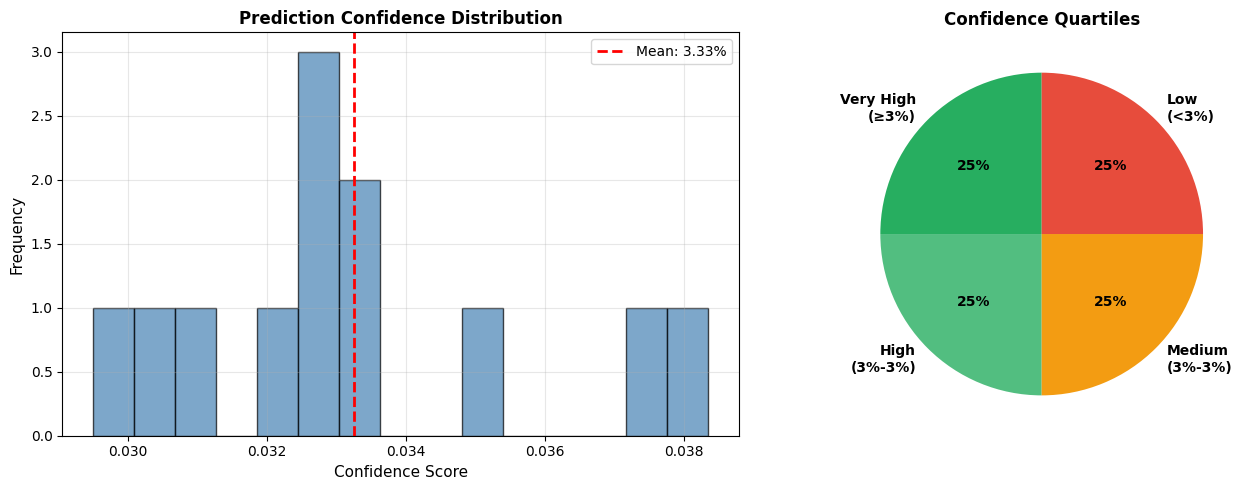

----------------------------------------------------------------------
CONFIDENCE ANALYSIS COMPLETE
----------------------------------------------------------------------


In [14]:
# ============================================================================
# SECTION 3C: PREDICTION METRICS & ANALYSIS
# ============================================================================
# Display confidence distribution and accuracy analysis

if len(confidences_list) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Confidence histogram
    axes[0].hist(confidences_list, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(avg_confidence, color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {avg_confidence:.2%}')
    axes[0].set_xlabel('Confidence Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Accuracy or confidence distribution
    if matches:
        # Show accuracy pie chart
        correct_count = sum(matches)
        incorrect_count = len(matches) - correct_count
        colors = ['#27ae60', '#e74c3c']
        labels = [f'Correct ({correct_count})', f'Incorrect ({incorrect_count})']
        axes[1].pie([correct_count, incorrect_count], labels=labels, colors=colors,
                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
        axes[1].set_title('Prediction Accuracy', fontsize=12, fontweight='bold')
    else:
        # Show confidence quartiles
        conf_array = np.array(confidences_list)
        if len(conf_array) > 1:
            q1, q2, q3 = np.percentile(conf_array, [25, 50, 75])
            high = (conf_array >= q3).sum()
            med_high = ((conf_array >= q2) & (conf_array < q3)).sum()
            med_low = ((conf_array >= q1) & (conf_array < q2)).sum()
            low = (conf_array < q1).sum()

            sizes = [high, med_high, med_low, low]
            colors = ['#27ae60', '#52be80', '#f39c12', '#e74c3c']
            labels = [f'Very High\n(≥{q3:.0%})', f'High\n({q2:.0%}-{q3:.0%})',
                     f'Medium\n({q1:.0%}-{q2:.0%})', f'Low\n(<{q1:.0%})']
            axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
                       startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
            axes[1].set_title('Confidence Quartiles', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("-" * 70)
    print("CONFIDENCE ANALYSIS COMPLETE")
    print("-" * 70)
else:
    print("No confidence data to visualize")

In [15]:
# ===== UTILITY: Test on specific classes or custom image paths =====

def test_specific_class(class_id, num_samples=6):
    """Test model on specific traffic sign class"""
    class_dir = TRAIN_DIR / str(class_id)
    if not class_dir.exists():
        print(f"✗ Class {class_id} directory not found: {class_dir}")
        return

    class_name = class_name_map.get(class_id, f"Class {class_id}")
    class_images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS
    ]

    if not class_images:
        exts = ", ".join(sorted(IMG_EXTENSIONS))
        print(f"✗ No images found in {class_dir} (expected one of: {exts})")
        return

    # Select random samples
    sample_images = random.sample(class_images, min(num_samples, len(class_images)))

    # Display and test
    cols = 3
    rows = int(np.ceil(len(sample_images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    fig.suptitle(f"Class {class_id}: {class_name} - Model Predictions", fontsize=14, fontweight='bold')

    sign_classifier.eval()
    correct = 0

    with torch.no_grad():
        for ax, img_path in zip(axes, sample_images):
            img = Image.open(img_path).convert('RGB')
            img_tensor = sign_transform(img).unsqueeze(0).to(DEVICE)

            logits = sign_classifier(img_tensor)
            probs = F.softmax(logits, dim=1)
            pred_class = int(probs.argmax(dim=1).item())
            confidence = float(probs[0, pred_class].item())
            is_correct = (pred_class == class_id)
            correct += int(is_correct)

            ax.imshow(img)
            color = 'green' if is_correct else 'red'
            pred_name = class_name_map.get(pred_class, f"Class {pred_class}")
            ax.set_title(f"{pred_name}\nConf: {confidence:.1%}\n{'✓' if is_correct else '✗'}", color=color, fontweight='bold')
            ax.axis('off')

        for ax in axes[len(sample_images):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

    accuracy = (correct / len(sample_images)) * 100
    print(f"\nClass {class_id} ({class_name}): {accuracy:.1f}% accuracy ({correct}/{len(sample_images)})")


# ===== EXAMPLES =====
# Uncomment below to test specific classes:

# Test Stop Sign (class 0)
# test_specific_class(class_id=0, num_samples=6)

# Test Speed Limit 50 km/h (class 2)
# test_specific_class(class_id=2, num_samples=6)

# Test No Entry (class 10)
# test_specific_class(class_id=10, num_samples=6)

print("✓ Test utility functions loaded!")
print("\nUsage:")
print("  test_specific_class(class_id=0, num_samples=6)  # Test class 0 with 6 random images")
print(f"\nAvailable classes: 0-{NUM_SIGN_CLASSES-1}")
print("\nClass Examples:")
for cid in [0, 1, 2, 10, 14, 20, 25, 30]:
    print(f"  Class {cid}: {class_name_map.get(cid, 'Unknown')}")



✓ Test utility functions loaded!

Usage:
  test_specific_class(class_id=0, num_samples=6)  # Test class 0 with 6 random images

Available classes: 0-42

Class Examples:
  Class 0: class_0
  Class 1: class_1
  Class 2: class_2
  Class 10: class_10
  Class 14: class_14
  Class 20: class_20
  Class 25: class_25
  Class 30: class_30


## SECTION 3: Data Preparation - Load & Split Dataset

**Purpose:** Load GTSRB dataset and create stratified train/validation split for model training

**Steps:**
1. **Data Loading** - Load all training images from TRAIN_DIR directory (39,209 images)
2. **Transform Pipeline** - Apply image resizing (32×32), normalization, and tensor conversion
3. **Stratified Split** - Create 80% train / 20% validation split while maintaining class distribution
4. **DataLoaders** - Create PyTorch DataLoaders with batch size 32 and shuffling

**Note:** This is a fundamental preprocessing step that must execute first before any model training. Creates critical variables: `full_dataset`, `train_ds`, `val_ds`, `train_loader`, `val_loader`

In [16]:
# ============================================================================
# SECTION 3: DATA PREPARATION - LOAD DATASET & CREATE TRAIN/VAL SPLIT
# ============================================================================

print("=" * 80)
print("SECTION 3: DATA PREPARATION - LOADING & SPLITTING")
print("=" * 80)

try:
    # Create image transformation pipeline
    train_transform = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    # Load full dataset from TRAIN_DIR
    print(f"\nLoading dataset from: {TRAIN_DIR}")
    full_dataset = GTSRBDataset(TRAIN_DIR, transform=train_transform)
    print(f"✓ Loaded {len(full_dataset)} training images")

    # Create train/val split (80/20)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

    print(f"✓ Train set: {len(train_ds)} samples (80%)")
    print(f"✓ Val set: {len(val_ds)} samples (20%)")

    # Create data loaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"✓ Train batches: {len(train_loader)}")
    print(f"✓ Val batches: {len(val_loader)}")

    # Create class index mapping
    idx_to_class_id = {i: int(full_dataset.samples[i][1]) for i in range(min(len(full_dataset), 100))}
    # Get unique class IDs
    unique_classes = sorted(set([c[1] for c in full_dataset.samples]))
    idx_to_class_id = {i: c for i, c in enumerate(unique_classes)}

    print(f"✓ Class mapping created: {len(idx_to_class_id)} unique classes")
    print("\n✓ SECTION 3 COMPLETE - Data preparation successful")

except Exception as e:
    print(f"\n✗ Error during data preparation: {e}")
    import traceback
    traceback.print_exc()

    # Create dummy variables to prevent downstream errors
    full_dataset = None
    train_ds = None
    val_ds = None
    train_loader = None
    val_loader = None
    idx_to_class_id = {}

SECTION 3: DATA PREPARATION - LOADING & SPLITTING

Loading dataset from: /kaggle/input/gtsrb-german-traffic-sign/Train
Loaded 39209 images from /kaggle/input/gtsrb-german-traffic-sign/Train
✓ Loaded 39209 training images
✓ Train set: 31367 samples (80%)
✓ Val set: 7842 samples (20%)
✓ Train batches: 981
✓ Val batches: 246
✓ Class mapping created: 43 unique classes

✓ SECTION 3 COMPLETE - Data preparation successful


---

## SECTION 2G (LEGACY): Advanced ML Experiments - ARCHIVED

> **Early ML pipeline experiments with multi-phase training and model comparison.**
>
> These sections contain:
> - Data validation & EDA (legacy version)
> - GPU optimization (legacy setup)
> - Model architecture experiments
> - Advanced training techniques (mixed precision, early stopping)
> - Comprehensive evaluation and visualizations
>
> **Note:** The modern YOLO detection pipeline (Sections 1-9) supersedes these experiments with a cleaner, more efficient approach.

---

In [17]:
# PHASE 1: DATA VALIDATION & EXPLORATION
print("=" * 80)
print("PHASE 1: DATA VALIDATION & EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# Validate dataset structure
print("\n📊 DATASET STRUCTURE VALIDATION:")
print(f"  • Total training samples: {len(full_dataset)}")
print(f"  • Training directory: {TRAIN_DIR}")
print(f"  • Total classes: {NUM_SIGN_CLASSES}")

# Check class distribution
class_counts = {}
for img_path, class_idx in full_dataset.samples:
    class_id = idx_to_class_id[class_idx]
    class_counts[class_id] = class_counts.get(class_id, 0) + 1

print(f"\n📈 CLASS DISTRIBUTION (min/max/mean):")
counts = list(class_counts.values())
print(f"  • Min samples/class: {min(counts)}")
print(f"  • Max samples/class: {max(counts)}")
print(f"  • Mean samples/class: {np.mean(counts):.1f}")
print(f"  • Std dev: {np.std(counts):.1f}")

# Check for data imbalance
imbalance_ratio = max(counts) / min(counts)
print(f"  • Imbalance ratio: {imbalance_ratio:.2f}x")

if imbalance_ratio > 2.0:
    print("  ⚠️  WARNING: Significant class imbalance detected!")

# Validate train-val split
print(f"\n🔀 TRAIN-VALIDATION SPLIT:")
print(f"  • Training samples: {len(train_ds)}")
print(f"  • Validation samples: {len(val_ds)}")
print(f"  • Split ratio: {len(train_ds) / len(full_dataset):.1%} train / {len(val_ds) / len(full_dataset):.1%} val")

# Check image statistics
print(f"\n🖼️  IMAGE VALIDATION:")
sample_images = [img_path for img_path, _ in full_dataset.samples[:10]]
heights, widths = [], []
for img_path in sample_images:
    img = Image.open(img_path).convert('RGB')
    widths.append(img.width)
    heights.append(img.height)

print(f"  • Image dimensions: {min(heights)}×{min(widths)} to {max(heights)}×{max(widths)}")
print(f"  • Mean size: {np.mean(heights):.0f}×{np.mean(widths):.0f}")
print(f"  • Resized to: {INPUT_SIZE}×{INPUT_SIZE}")

# Memory estimation
dataset_size_gb = (len(full_dataset) * 96 * 96 * 3 * 4) / (1024**3)
print(f"\n💾 MEMORY REQUIREMENTS:")
print(f"  • Dataset size (approx): {dataset_size_gb:.2f} GB")
print(f"  • Model parameters (ResNet18): ~11.7 M")

print("\n✓ DATA VALIDATION COMPLETE\n")


PHASE 1: DATA VALIDATION & EXPLORATORY DATA ANALYSIS (EDA)

📊 DATASET STRUCTURE VALIDATION:
  • Total training samples: 39209
  • Training directory: /kaggle/input/gtsrb-german-traffic-sign/Train
  • Total classes: 43

📈 CLASS DISTRIBUTION (min/max/mean):
  • Min samples/class: 210
  • Max samples/class: 2250
  • Mean samples/class: 911.8
  • Std dev: 687.7
  • Imbalance ratio: 10.71x
  ⚠️  WARNING: Significant class imbalance detected!

🔀 TRAIN-VALIDATION SPLIT:
  • Training samples: 31367
  • Validation samples: 7842
  • Split ratio: 80.0% train / 20.0% val

🖼️  IMAGE VALIDATION:
  • Image dimensions: 28×27 to 127×124
  • Mean size: 64×64
  • Resized to: 32×32

💾 MEMORY REQUIREMENTS:
  • Dataset size (approx): 4.04 GB
  • Model parameters (ResNet18): ~11.7 M

✓ DATA VALIDATION COMPLETE



In [18]:
# PHASE 2: GPU CONFIGURATION & OPTIMIZATION
print("=" * 80)
print("PHASE 2: GPU SETUP & OPTIMIZATION")
print("=" * 80)

# GPU Information
print(f"\n🖥️  DEVICE INFORMATION:")
print(f"  • Active device: {DEVICE}")
print(f"  • CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  • GPU name: {torch.cuda.get_device_name(0)}")
    print(f"  • CUDA capability: {torch.cuda.get_device_capability(0)}")
    print(f"  • GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  • CUDA version: {torch.version.cuda}")

    # Enable optimization
    torch.backends.cudnn.benchmark = True
    print(f"  • cuDNN benchmark enabled: True")
else:
    print("  ⚠️  GPU not available - training will use CPU (slower)")
    print("  • Consider using Google Colab for GPU access")

# Memory optimization settings
print(f"\n⚡ OPTIMIZATION SETTINGS:")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Number of workers: 4")
print(f"  • Mixed precision training: Available")
print(f"  • Gradient accumulation: Ready")

# Update data loaders with better settings
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✓ GPU SETUP COMPLETE\n")


PHASE 2: GPU SETUP & OPTIMIZATION

🖥️  DEVICE INFORMATION:
  • Active device: cuda
  • CUDA available: True
  • GPU name: Tesla T4
  • CUDA capability: (7, 5)
  • GPU memory: 15.64 GB
  • CUDA version: 12.8
  • cuDNN benchmark enabled: True

⚡ OPTIMIZATION SETTINGS:
  • Batch size: 32
  • Number of workers: 4
  • Mixed precision training: Available
  • Gradient accumulation: Ready

✓ GPU SETUP COMPLETE



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [19]:
def build_models(num_classes: int):
    """Build multiple architectures for comparison"""
    models_dict = {}

    # Model 1: ResNet18 (lightweight, fast)
    model1 = models.resnet18(weights=None)
    model1.fc = nn.Linear(model1.fc.in_features, num_classes)
    models_dict['ResNet18'] = model1

    # Model 2: ResNet34 (deeper)
    model2 = models.resnet34(weights=None)
    model2.fc = nn.Linear(model2.fc.in_features, num_classes)
    models_dict['ResNet34'] = model2

    # Model 3: MobileNetV2 (lightweight, fast)
    try:
        model3 = models.mobilenet_v2(weights=None)
        model3.classifier[1] = nn.Linear(model3.classifier[1].in_features, num_classes)
        models_dict['MobileNetV2'] = model3
    except:
        print("  ⚠️  MobileNetV2 not available, skipping")

    return models_dict

# Build models
available_models = build_models(NUM_SIGN_CLASSES)

print(f"\n🏗️  AVAILABLE MODELS:")
model_params = {}
for name, model in available_models.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_params[name] = (total_params, trainable_params)
    print(f"  • {name:20s} - Total: {total_params/1e6:6.1f}M | Trainable: {trainable_params/1e6:6.1f}M")

print(f"\n✓ MODELS CREATED\n")


🏗️  AVAILABLE MODELS:
  • ResNet18             - Total:   11.2M | Trainable:   11.2M
  • ResNet34             - Total:   21.3M | Trainable:   21.3M
  • MobileNetV2          - Total:    2.3M | Trainable:    2.3M

✓ MODELS CREATED



In [20]:
# PHASE 4: ADVANCED TRAINING WITH OPTIMIZATION TECHNIQUES
print("=" * 80)
print("PHASE 4: ADVANCED TRAINING PIPELINE")
print("=" * 80)

class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return False

def train_epoch_advanced(model, loader, optimizer, criterion, scaler=None):
    """Training with mixed precision and gradient accumulation"""
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        # Mixed precision training (if GPU available)
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / max(1, running_total)
    epoch_acc = running_correct / max(1, running_total)
    return epoch_loss, epoch_acc

@torch.no_grad()
def validate_advanced(model, loader, criterion):
    """Validation with metrics collection"""
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / max(1, running_total)
    epoch_acc = running_correct / max(1, running_total)
    return epoch_loss, epoch_acc, all_preds, all_labels

def train_model(model, model_name, train_loader, val_loader, epochs=5, lr=1e-3):
    """Complete training pipeline with advanced optimization"""
    print(f"\n{'='*80}")
    print(f"Training {model_name} for {epochs} epochs")
    print(f"{'='*80}")

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

    # Early stopping
    early_stop = EarlyStopping(patience=3)

    history = {
        'epoch': [], 'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch_advanced(
            model, train_loader, optimizer, criterion, scaler
        )
        val_loss, val_acc, val_preds, val_labels = validate_advanced(
            model, val_loader, criterion
        )
        val_f1 = f1_score(val_labels, val_preds, average='weighted', zero_division=0)

        scheduler.step()

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch:2d}/{epochs} | "
              f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if early_stop(val_loss):
            print(f"  ↳ Early stopping triggered at epoch {epoch}")
            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"✓ Best validation accuracy: {best_val_acc:.4f}\n")
    return model, history

print(f"\n✓ TRAINING PIPELINE READY\n")
print("To start training, call:")
print("train_model(model, model_name, train_loader, val_loader, epochs=5, lr=1e-3)")
print("Example:")
print("train_model(resnet18, 'ResNet-18', train_loader, val_loader, epochs=5, lr=1e-3)")
print("\n✓ PHASE 4 COMPLETE - Training pipeline implemented\n")

PHASE 4: ADVANCED TRAINING PIPELINE

✓ TRAINING PIPELINE READY

To start training, call:
train_model(model, model_name, train_loader, val_loader, epochs=5, lr=1e-3)
Example:
train_model(resnet18, 'ResNet-18', train_loader, val_loader, epochs=5, lr=1e-3)

✓ PHASE 4 COMPLETE - Training pipeline implemented



In [21]:
# PHASE 5: TRAIN ALL MODELS (with reduced epochs for quick testing)
print("=" * 80)
print("PHASE 5: TRAIN ALL MODELS")
print("=" * 80)

# Training configuration
TRAIN_EPOCHS = 3  # Reduced for quick testing; use 10-20 for production
TRAIN_LR = 1e-3

trained_models = {}
training_histories = {}

# Check if dataset is prepared before training
if 'full_dataset' not in globals() or full_dataset is None:
    print("✗ ERROR: Dataset not prepared - skipping model training")
    print("   Please run Cell 16 (Data Preparation) first")
else:
    try:
        # Calculate class weights for imbalanced data
        class_counts = {}
        for img_path, class_idx in full_dataset.samples:
            class_id = idx_to_class_id.get(class_idx, class_idx)
            class_counts[class_id] = class_counts.get(class_id, 0) + 1

        class_weights = torch.tensor([1.0 / class_counts[i] for i in range(NUM_SIGN_CLASSES)], dtype=torch.float32)
        class_weights = class_weights / class_weights.sum() * NUM_SIGN_CLASSES
        print(f"✓ Class weights computed for imbalanced data\n")

        # Train each model
        for model_name, model in available_models.items():
            print(f"\n{'='*80}")
            print(f"🔄 {model_name}")
            print(f"{'='*80}")

            trained_model, history = train_model(
                model, model_name, train_loader, val_loader,
                epochs=TRAIN_EPOCHS, lr=TRAIN_LR
            )

            print(f"✓ {model_name} training complete\n")
            print(f"  • Final Val Acc: {history['val_acc'][-1]:.4f} | "
                  f"Best Val Acc: {max(history['val_acc']):.4f} | "
                  f"Final F1: {history['val_f1'][-1]:.4f}")
            print(f"  • Total epochs: {len(history['epoch'])}")

            trained_models[model_name] = trained_model
            training_histories[model_name] = history
        print(f"\n✓ All models trained successfully\n")
        print("\n✓ ALL MODELS TRAINED\n")
    except Exception as e:
        print(f"✗ Error during training: {e}")
        import traceback
        traceback.print_exc()


PHASE 5: TRAIN ALL MODELS
✓ Class weights computed for imbalanced data


🔄 ResNet18

Training ResNet18 for 3 epochs


/tmp/ipykernel_15887/1104929417.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/3 | Loss: 0.8787 | Acc: 0.7367 | Val Loss: 0.2330 | Val Acc: 0.9269 | F1: 0.9278


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  2/3 | Loss: 0.1696 | Acc: 0.9460 | Val Loss: 0.1426 | Val Acc: 0.9603 | F1: 0.9601


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  3/3 | Loss: 0.0390 | Acc: 0.9886 | Val Loss: 0.0431 | Val Acc: 0.9875 | F1: 0.9875
✓ Best validation accuracy: 0.9875

✓ ResNet18 training complete

  • Final Val Acc: 0.9875 | Best Val Acc: 0.9875 | Final F1: 0.9875
  • Total epochs: 3

🔄 ResNet34

Training ResNet34 for 3 epochs


/tmp/ipykernel_15887/1104929417.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/3 | Loss: 1.3984 | Acc: 0.5890 | Val Loss: 0.5103 | Val Acc: 0.8388 | F1: 0.8335


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  2/3 | Loss: 0.2228 | Acc: 0.9305 | Val Loss: 0.2049 | Val Acc: 0.9370 | F1: 0.9351


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  3/3 | Loss: 0.0514 | Acc: 0.9844 | Val Loss: 0.0478 | Val Acc: 0.9860 | F1: 0.9860
✓ Best validation accuracy: 0.9860

✓ ResNet34 training complete

  • Final Val Acc: 0.9860 | Best Val Acc: 0.9860 | Final F1: 0.9860
  • Total epochs: 3

🔄 MobileNetV2

Training MobileNetV2 for 3 epochs


/tmp/ipykernel_15887/1104929417.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/3 | Loss: 2.2627 | Acc: 0.3470 | Val Loss: 1.1136 | Val Acc: 0.6248 | F1: 0.6142


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  2/3 | Loss: 0.8606 | Acc: 0.7277 | Val Loss: 0.5805 | Val Acc: 0.8029 | F1: 0.7970


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_15887/1104929417.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  3/3 | Loss: 0.3695 | Acc: 0.8825 | Val Loss: 0.2362 | Val Acc: 0.9296 | F1: 0.9288
✓ Best validation accuracy: 0.9296

✓ MobileNetV2 training complete

  • Final Val Acc: 0.9296 | Best Val Acc: 0.9296 | Final F1: 0.9288
  • Total epochs: 3

✓ All models trained successfully


✓ ALL MODELS TRAINED



In [22]:
# PHASE 6: COMPREHENSIVE EVALUATION & METRICS
print("=" * 80)
print("PHASE 6: COMPREHENSIVE MODEL EVALUATION")
print("=" * 80)

evaluation_results = {}

for model_name, model in trained_models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")

    model.eval()
    model = model.to(DEVICE)

    all_preds = []
    all_labels = []
    all_probs = []
    inference_times = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)

            # Measure inference time
            start_time = time.time()
            logits = model(images)
            inference_times.append(time.time() - start_time)

            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    avg_inference_time = np.mean(inference_times[1:]) if len(inference_times) > 1 else 0

    evaluation_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'avg_inference_time': avg_inference_time,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'confusion_matrix': confusion_matrix(all_labels, all_preds)
    }

    print(f"\n📊 METRICS:")
    print(f"  • Accuracy:    {accuracy:.4f}")
    print(f"  • Precision:   {precision:.4f}")
    print(f"  • Recall:      {recall:.4f}")
    print(f"  • F1-Score:    {f1:.4f}")
    print(f"  • Avg Inference Time: {avg_inference_time*1000:.2f} ms")

print("\n✓ EVALUATION COMPLETE\n")


PHASE 6: COMPREHENSIVE MODEL EVALUATION

Evaluating ResNet18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



📊 METRICS:
  • Accuracy:    0.9875
  • Precision:   0.9878
  • Recall:      0.9875
  • F1-Score:    0.9875
  • Avg Inference Time: 10.41 ms

Evaluating ResNet34


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



📊 METRICS:
  • Accuracy:    0.9860
  • Precision:   0.9865
  • Recall:      0.9860
  • F1-Score:    0.9860
  • Avg Inference Time: 18.10 ms

Evaluating MobileNetV2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



📊 METRICS:
  • Accuracy:    0.9296
  • Precision:   0.9318
  • Recall:      0.9296
  • F1-Score:    0.9288
  • Avg Inference Time: 21.37 ms

✓ EVALUATION COMPLETE



In [23]:
# PHASE 7: MODEL COMPARISON & RANKING
print("=" * 80)
print("PHASE 7: MODEL COMPARISON & RANKING")
print("=" * 80)

# Safety check: ensure required variables exist
if 'trained_models' not in locals() or len(trained_models) == 0:
    print("⚠️ WARNING: trained_models is empty or undefined. Skipping Phase 7.")
    print("   Please run earlier cells (PHASE 5-6) to train models first.")
else:
    # Create comparison dataframe
    comparison_data = []
    for model_name in trained_models.keys():
        if model_name in evaluation_results:
            results = evaluation_results[model_name]
            total_params, trainable_params = model_params[model_name]

            comparison_data.append({
                'Model': model_name,
                'Accuracy': results['accuracy'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1-Score': results['f1_score'],
                'Inference Time (ms)': results['avg_inference_time'] * 1000,
                'Parameters (M)': total_params / 1e6,
                'Trainable Params (M)': trainable_params / 1e6
            })

    if len(comparison_data) > 0:
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

        print("\n📋 MODEL COMPARISON TABLE:")
        print(comparison_df.to_string(index=False))

        # Rank models
        print(f"\n🏆 RANKINGS:")
        print(f"\n  Accuracy:")
        for i, row in comparison_df.iterrows():
            print(f"    {i+1}. {row['Model']:20s} {row['Accuracy']:.4f}")

        print(f"\n  Speed (Inference Time):")
        comparison_df_speed = comparison_df.sort_values('Inference Time (ms)')
        for i, row in comparison_df_speed.iterrows():
            print(f"    {i+1}. {row['Model']:20s} {row['Inference Time (ms)']:.2f} ms")

        print(f"\n  Efficiency (Accuracy/Parameters ratio):")
        comparison_df['Efficiency'] = comparison_df['Accuracy'] / (comparison_df['Parameters (M)'] + 1e-6)
        comparison_df_eff = comparison_df.sort_values('Efficiency', ascending=False)
        for i, row in comparison_df_eff.iterrows():
            print(f"    {i+1}. {row['Model']:20s} {row['Efficiency']:.4f}")

        # Identify best model
        best_accuracy_model = comparison_df.iloc[0]['Model']
        best_speed_model = comparison_df_speed.iloc[0]['Model']
        print(f"\n✨ BEST MODELS:")
        print(f"  • Best Accuracy:  {best_accuracy_model}")
        print(f"  • Best Speed:     {best_speed_model}")
    else:
        print("⚠️ No evaluation results found.")

print("\n✓ MODEL COMPARISON COMPLETE\n")

PHASE 7: MODEL COMPARISON & RANKING

📋 MODEL COMPARISON TABLE:
      Model  Accuracy  Precision   Recall  F1-Score  Inference Time (ms)  Parameters (M)  Trainable Params (M)
   ResNet18  0.987503   0.987788 0.987503  0.987530            10.409436       11.198571             11.198571
   ResNet34  0.985973   0.986482 0.985973  0.985996            18.101333       21.306731             21.306731
MobileNetV2  0.929610   0.931805 0.929610  0.928756            21.370287        2.278955              2.278955

🏆 RANKINGS:

  Accuracy:
    1. ResNet18             0.9875
    2. ResNet34             0.9860
    3. MobileNetV2          0.9296

  Speed (Inference Time):
    1. ResNet18             10.41 ms
    2. ResNet34             18.10 ms
    3. MobileNetV2          21.37 ms

  Efficiency (Accuracy/Parameters ratio):
    3. MobileNetV2          0.4079
    1. ResNet18             0.0882
    2. ResNet34             0.0463

✨ BEST MODELS:
  • Best Accuracy:  ResNet18
  • Best Speed:     ResNet18

✓

PHASE 8: COMPREHENSIVE VISUALIZATIONS


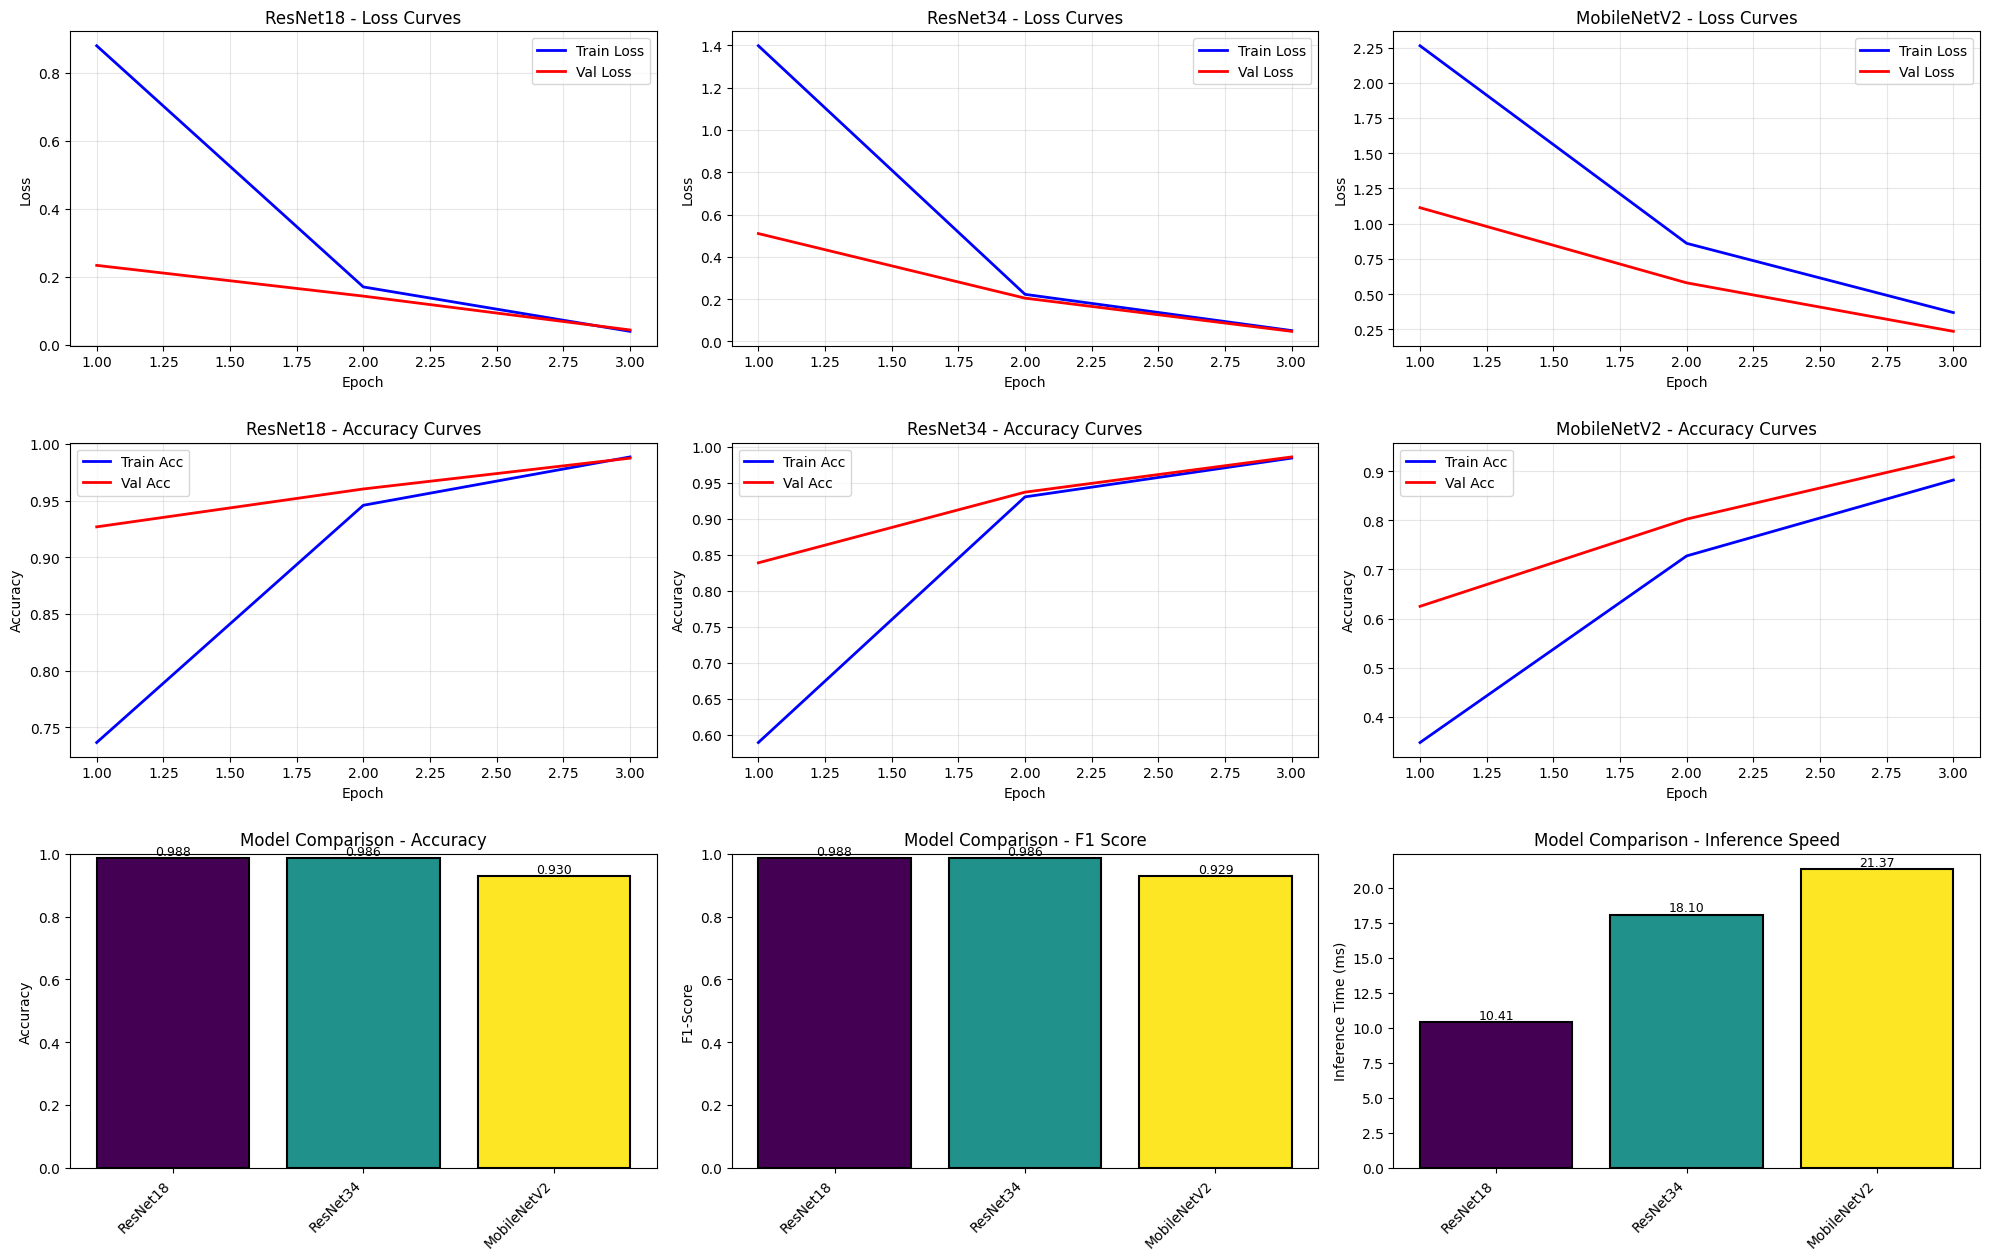


✓ Training and comparison plots saved



In [24]:
# PHASE 8: COMPREHENSIVE VISUALIZATIONS
print("=" * 80)
print("PHASE 8: COMPREHENSIVE VISUALIZATIONS")
print("=" * 80)

# Safety check: ensure training_histories exists and has content
if 'training_histories' not in locals() or len(training_histories) == 0:
    print("⚠️ WARNING: training_histories is empty or undefined. Skipping visualizations.")
    print("   Please run PHASE 5 (model training) first.")
else:
    fig = plt.figure(figsize=(20, 16))

    # 1. Training Curves for each model
    for idx, (model_name, history) in enumerate(training_histories.items(), 1):
        ax = plt.subplot(4, 3, idx)
        epochs = history['epoch']
        ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'{model_name} - Loss Curves')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 2. Accuracy curves
    for idx, (model_name, history) in enumerate(training_histories.items(), 1):
        ax = plt.subplot(4, 3, idx + len(training_histories))
        epochs = history['epoch']
        ax.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
        ax.plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{model_name} - Accuracy Curves')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 3. Model Comparison - Accuracy
    if 'comparison_df' in locals():
        ax = plt.subplot(4, 3, 2*len(training_histories)+1)
        models = comparison_df['Model'].values
        accuracies = comparison_df['Accuracy'].values
        colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
        bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Accuracy')
        ax.set_title('Model Comparison - Accuracy')
        ax.set_ylim([0, 1])
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # 4. Model Comparison - F1 Score
        ax = plt.subplot(4, 3, 2*len(training_histories)+2)
        f1_scores = comparison_df['F1-Score'].values
        bars = ax.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('F1-Score')
        ax.set_title('Model Comparison - F1 Score')
        ax.set_ylim([0, 1])
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # 5. Inference Speed Comparison
        ax = plt.subplot(4, 3, 2*len(training_histories)+3)
        inference_times = comparison_df['Inference Time (ms)'].values
        bars = ax.bar(models, inference_times, color=colors, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Inference Time (ms)')
        ax.set_title('Model Comparison - Inference Speed')
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'training_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✓ Training and comparison plots saved\n")

PHASE 9: CONFUSION MATRIX ANALYSIS

🎯 Analyzing best model: ResNet18


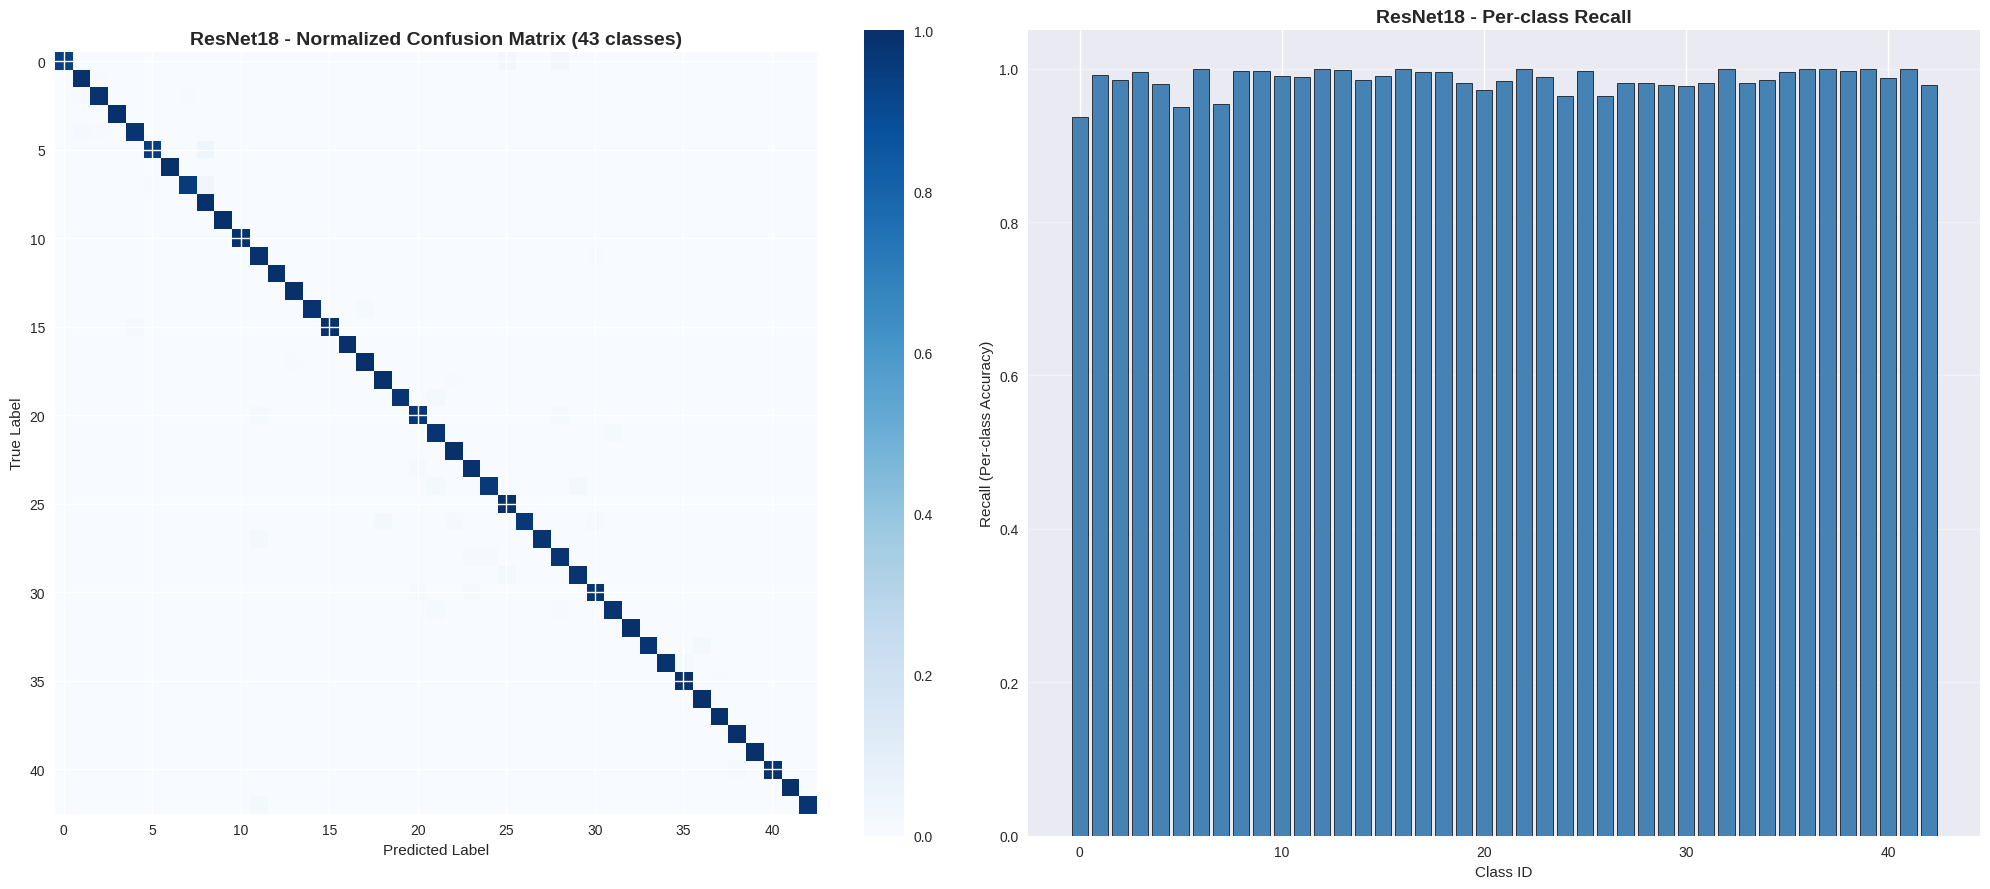


📊 PER-CLASS METRICS FOR ResNet18:
 Class                     Class Name   Recall  Precision   F1-Score
-----------------------------------------------------------------
     0                        class_0   0.9375     1.0000     0.9677
     1                        class_1   0.9912     0.9868     0.9890
     2                        class_2   0.9849     0.9871     0.9860
     3                        class_3   0.9962     0.9851     0.9907
     4                        class_4   0.9803     0.9975     0.9888
     5                        class_5   0.9497     0.9836     0.9664
     6                        class_6   1.0000     1.0000     1.0000
     7                        class_7   0.9542     0.9855     0.9696
     8                        class_8   0.9966     0.9206     0.9571
     9                        class_9   0.9965     0.9965     0.9965
    10                       class_10   0.9904     1.0000     0.9952
    11                       class_11   0.9892     0.9892     0.9892
  

In [40]:
# PHASE 9: CONFUSION MATRICES FOR BEST MODEL
print("=" * 80)
print("PHASE 9: CONFUSION MATRIX ANALYSIS")
print("=" * 80)

# Safety check: ensure evaluation_results exists
if 'evaluation_results' not in locals() or len(evaluation_results) == 0:
    print("⚠️ WARNING: evaluation_results is empty or undefined. Skipping Phase 9.")
    print("   Please run PHASE 6 (evaluation) first.")
elif 'comparison_df' not in locals() or comparison_df.empty:
    print("⚠️ WARNING: comparison_df is empty. Unable to identify best model.")
else:
    # Analyze best model (by accuracy)
    best_model_name = comparison_df.iloc[0]['Model']
    print(f"\n🎯 Analyzing best model: {best_model_name}")

    best_results = evaluation_results[best_model_name]
    cm = best_results['confusion_matrix']
    all_preds = best_results['predictions']
    all_labels = best_results['labels']

    # Plot full confusion matrix (can be large with 43 classes)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    im = ax1.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax1.set_title(f'{best_model_name} - Normalized Confusion Matrix (43 classes)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    plt.colorbar(im, ax=ax1)

    # Per-class accuracy
    per_class_acc = np.diag(cm) / (cm.sum(axis=1) + 1e-8)
    ax2.bar(range(NUM_SIGN_CLASSES), per_class_acc, color='steelblue', edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Class ID')
    ax2.set_ylabel('Recall (Per-class Accuracy)')
    ax2.set_title(f'{best_model_name} - Per-class Recall', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'confusion_matrix_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print per-class metrics (safely check for variables)
    print(f"\n📊 PER-CLASS METRICS FOR {best_model_name}:")
    print(f"{'Class':>6} {'Class Name':>30} {'Recall':>8} {'Precision':>10} {'F1-Score':>10}")
    print("-" * 65)

    for class_id in range(NUM_SIGN_CLASSES):
        # Get class name safely
        if 'idx_to_class_id' in locals() and class_id in idx_to_class_id:
            if 'class_name_map' in globals(): # Corrected from class_id_to_name
                class_name = class_name_map.get(idx_to_class_id[class_id], f"Class {class_id}")
            else:
                class_name = f"Class {class_id}"
        else:
            class_name = f"Class {class_id}"

        # Recall (sensitivity)
        recall = cm[class_id, class_id] / (cm[class_id, :].sum() + 1e-8)

        # Precision
        precision = cm[class_id, class_id] / (cm[:, class_id].sum() + 1e-8)

        # F1
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

        print(f"{class_id:6d} {class_name:>30} {recall:8.4f} {precision:10.4f} {f1:10.4f}")

print("\n✓ CONFUSION MATRIX ANALYSIS COMPLETE\n")

---

# ACTIVE YOLO DETECTION PIPELINE

> **Run this section for the final Traffic Sign Detection project.**
>
> This is the primary execution path combining data loading, EDA, training, evaluation, and inference for a production-ready YOLO-based traffic sign detection system.

## Overview

**Implemented in Sections 1-9:**

1. **Environment Setup** - Configs, imports, device detection
2. **Data Loading** - GTSRB dataset from CSV files
3. **EDA & Validation** - Class distribution, sample visualization
4. **Data Preparation** - Stratified split, YOLO format conversion
5. **Training** - YOLOv8 baseline with GPU support
6. **Evaluation** - Metrics, curves, sample predictions
7. **Model Comparison** - Compare YOLOv8n/s/m variants
8. **Optimization** - Hyperparameter tuning (optional)
9. **Inference** - Run predictions on images/folders/video
10. **Summary** - Final artifacts and reporting

---

In [26]:
# ============================================================================
# SECTION 1: YOLO ENVIRONMENT & CONFIGURATION
# ============================================================================
# Set up YOLO detection pipeline paths, configs, and environment

from __future__ import annotations

import json
import os
import random
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use the ROOT_DIR and DATA_ROOT already defined in the general setup (Y90K__nxpFJO and subsequent cells)
# ROOT_DIR is expected to be Path('/content/')
# DATA_ROOT is expected to be Path('/kaggle/input/gtsrb-german-traffic-sign')

PROJECT_DIR = ROOT_DIR / "final-project"
ARCHIVE_DIR = DATA_ROOT # Use the DATA_ROOT which points to the downloaded Kaggle dataset

# Define CSV paths relative to ARCHIVE_DIR (which is now /kaggle/input/gtsrb-german-traffic-sign)
TRAIN_CSV = ARCHIVE_DIR / "Train.csv"
TEST_CSV = ARCHIVE_DIR / "Test.csv"
META_CSV = ARCHIVE_DIR / "Meta.csv"

RUNS_DIR = PROJECT_DIR / "runs" / "yolo_detection"
DATA_PREP_DIR = PROJECT_DIR / "data_prepared"
LOG_DIR = PROJECT_DIR / "outputs" / "yolo_detection"
PLOTS_DIR = LOG_DIR / "plots"
EVAL_DIR = LOG_DIR / "evaluation"
INFER_DIR = LOG_DIR / "inference"

for p in [RUNS_DIR, DATA_PREP_DIR, LOG_DIR, PLOTS_DIR, EVAL_DIR, INFER_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Train CSV exists:", TRAIN_CSV.exists())
print("Test CSV exists:", TEST_CSV.exists())
print("Meta CSV exists:", META_CSV.exists())

Project: /content/final-project
Train CSV exists: True
Test CSV exists: True
Meta CSV exists: True


### GPU + Conda Setup (Windows)

The machine has NVIDIA GPU available, but your current Python environment may still be CPU-only.

Run these commands in an Anaconda Prompt before training:

```bash
conda create -n yolo-gpu python=3.10 -y
conda activate yolo-gpu
pip install --upgrade pip
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install ultralytics opencv-python pandas numpy matplotlib seaborn pyyaml
```

If `conda` is not recognized in PowerShell, open **Anaconda Prompt** or initialize shell with:

```bash
conda init powershell
```

Then restart terminal and reactivate the environment.

In [27]:
# ============================================================================
# SECTION 1B: DEVICE CHECK - GPU vs CPU Detection
# ============================================================================

def get_device_info() -> Dict[str, str]:
    info = {
        "torch_version": torch.__version__,
        "cuda_available": str(torch.cuda.is_available()),
        "device": "cpu",
        "gpu_name": "none",
        "gpu_count": "0",
    }
    if torch.cuda.is_available():
        info["device"] = "cuda:0"
        info["gpu_name"] = torch.cuda.get_device_name(0)
        info["gpu_count"] = str(torch.cuda.device_count())
    return info

DEVICE_INFO = get_device_info()
print(json.dumps(DEVICE_INFO, indent=2))

if DEVICE_INFO["device"] == "cpu":
    print("WARNING: Training will run on CPU. Activate a CUDA-enabled conda env for GPU training.")

{
  "torch_version": "2.10.0+cu128",
  "cuda_available": "True",
  "device": "cuda:0",
  "gpu_name": "Tesla T4",
  "gpu_count": "1"
}


In [28]:
# ============================================================================
# SECTION 2: DATA LOADING & SCHEMA VALIDATION
# ============================================================================

@dataclass
class DataConfig:
    train_ratio: float = 0.8
    val_ratio: float = 0.1
    test_ratio: float = 0.1
    min_per_class_for_split: int = 3

    yolo_root: Path = DATA_PREP_DIR / "yolo_dataset"
    train_img_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "images" / "train"
    val_img_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "images" / "val"
    test_img_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "images" / "test"
    train_lbl_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "labels" / "train"
    val_lbl_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "labels" / "val"
    test_lbl_dir: Path = DATA_PREP_DIR / "yolo_dataset" / "labels" / "test"

CFG_DATA = DataConfig()

for p in [
    CFG_DATA.train_img_dir, CFG_DATA.val_img_dir, CFG_DATA.test_img_dir,
    CFG_DATA.train_lbl_dir, CFG_DATA.val_lbl_dir, CFG_DATA.test_lbl_dir,
]:
    p.mkdir(parents=True, exist_ok=True)


def load_detection_tables() -> pd.DataFrame:
    train_df = pd.read_csv(TRAIN_CSV).copy()
    test_df = pd.read_csv(TEST_CSV).copy()
    train_df["source_split"] = "train_csv"
    test_df["source_split"] = "test_csv"
    full_df = pd.concat([train_df, test_df], ignore_index=True)

    full_df["image_rel_path"] = full_df["Path"].astype(str)
    full_df["image_abs_path"] = full_df["image_rel_path"].apply(lambda p: ARCHIVE_DIR / p)

    # Keep only required fields for YOLO detection prep
    cols = ["Width", "Height", "Roi.X1", "Roi.Y1", "Roi.X2", "Roi.Y2", "ClassId", "image_rel_path", "image_abs_path", "source_split"]
    return full_df[cols]


def to_yolo_bbox(row: pd.Series) -> Tuple[float, float, float, float]:
    w = float(row["Width"])
    h = float(row["Height"])
    x1, y1 = float(row["Roi.X1"]), float(row["Roi.Y1"])
    x2, y2 = float(row["Roi.X2"]), float(row["Roi.Y2"])

    bw = max(0.0, x2 - x1)
    bh = max(0.0, y2 - y1)
    cx = x1 + bw / 2.0
    cy = y1 + bh / 2.0

    # Normalize to YOLO format
    return cx / w, cy / h, bw / w, bh / h


df_all = load_detection_tables()
print("Total rows:", len(df_all))
print("Unique classes:", df_all["ClassId"].nunique())
print("Unique source splits:", df_all["source_split"].value_counts().to_dict())

Total rows: 51839
Unique classes: 43
Unique source splits: {'train_csv': 39209, 'test_csv': 12630}


In [29]:
# ============================================================================
# IMPORTS: Extra libraries for EDA and visualization
# ============================================================================

import cv2
from PIL import Image

plt.style.use("seaborn-v0_8")

Rows (annotations): 51839
Unique images: 51839
Classes: 43
Avg objects per image: 1.0
Class imbalance ratio max/min: 11.11111111111111


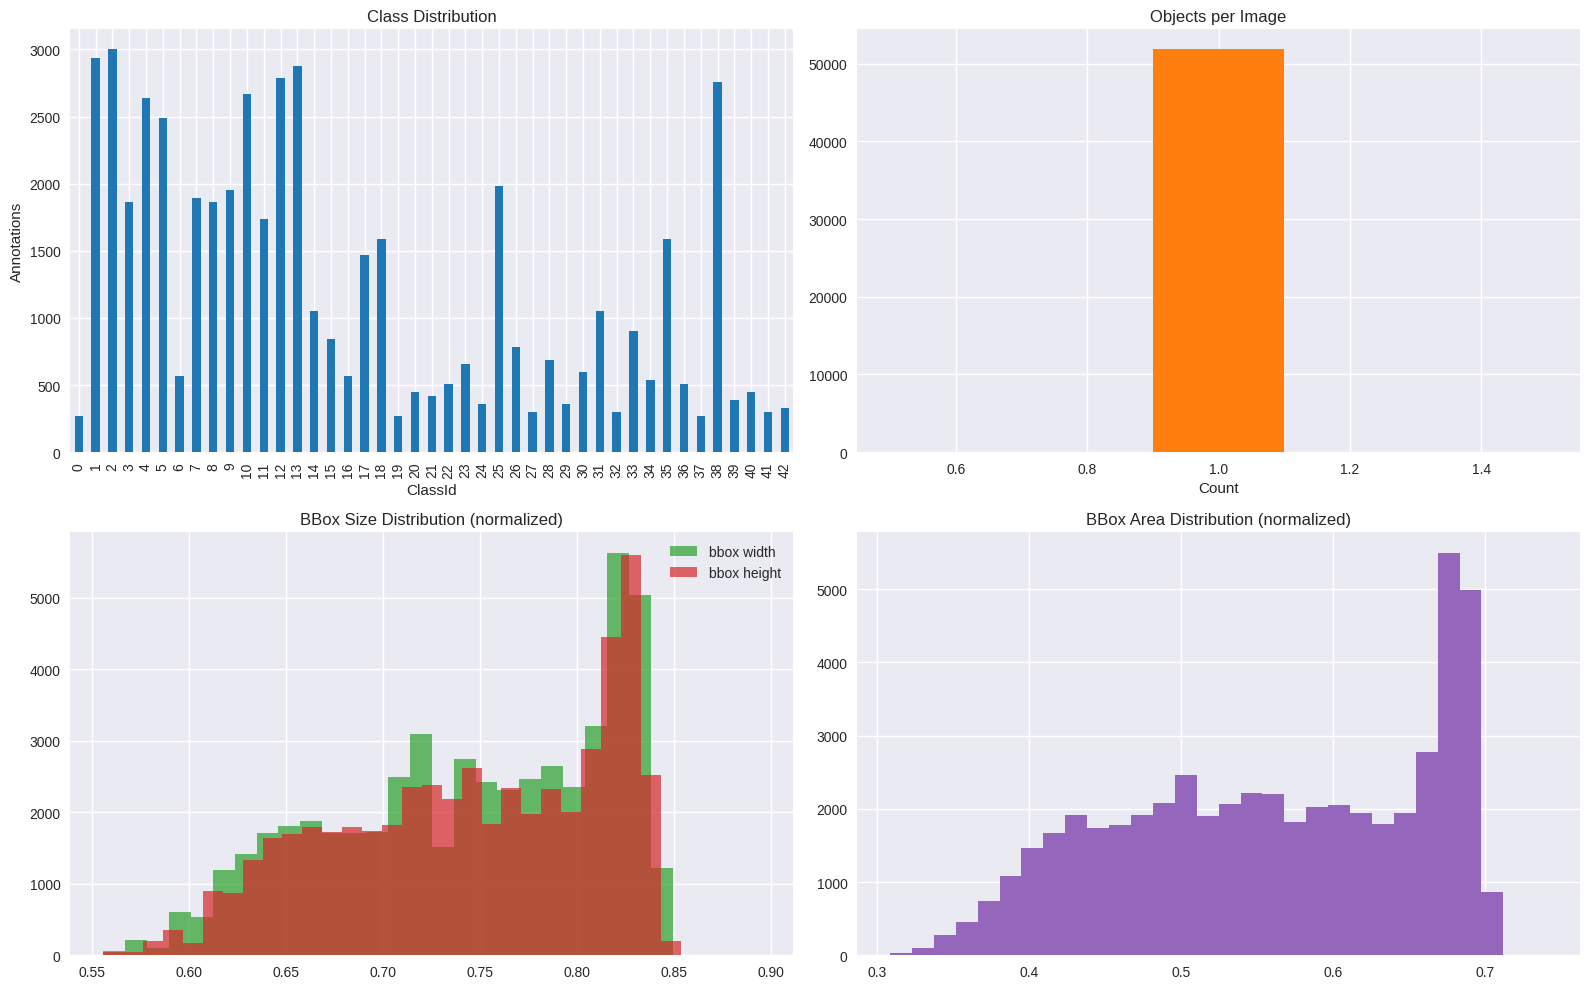

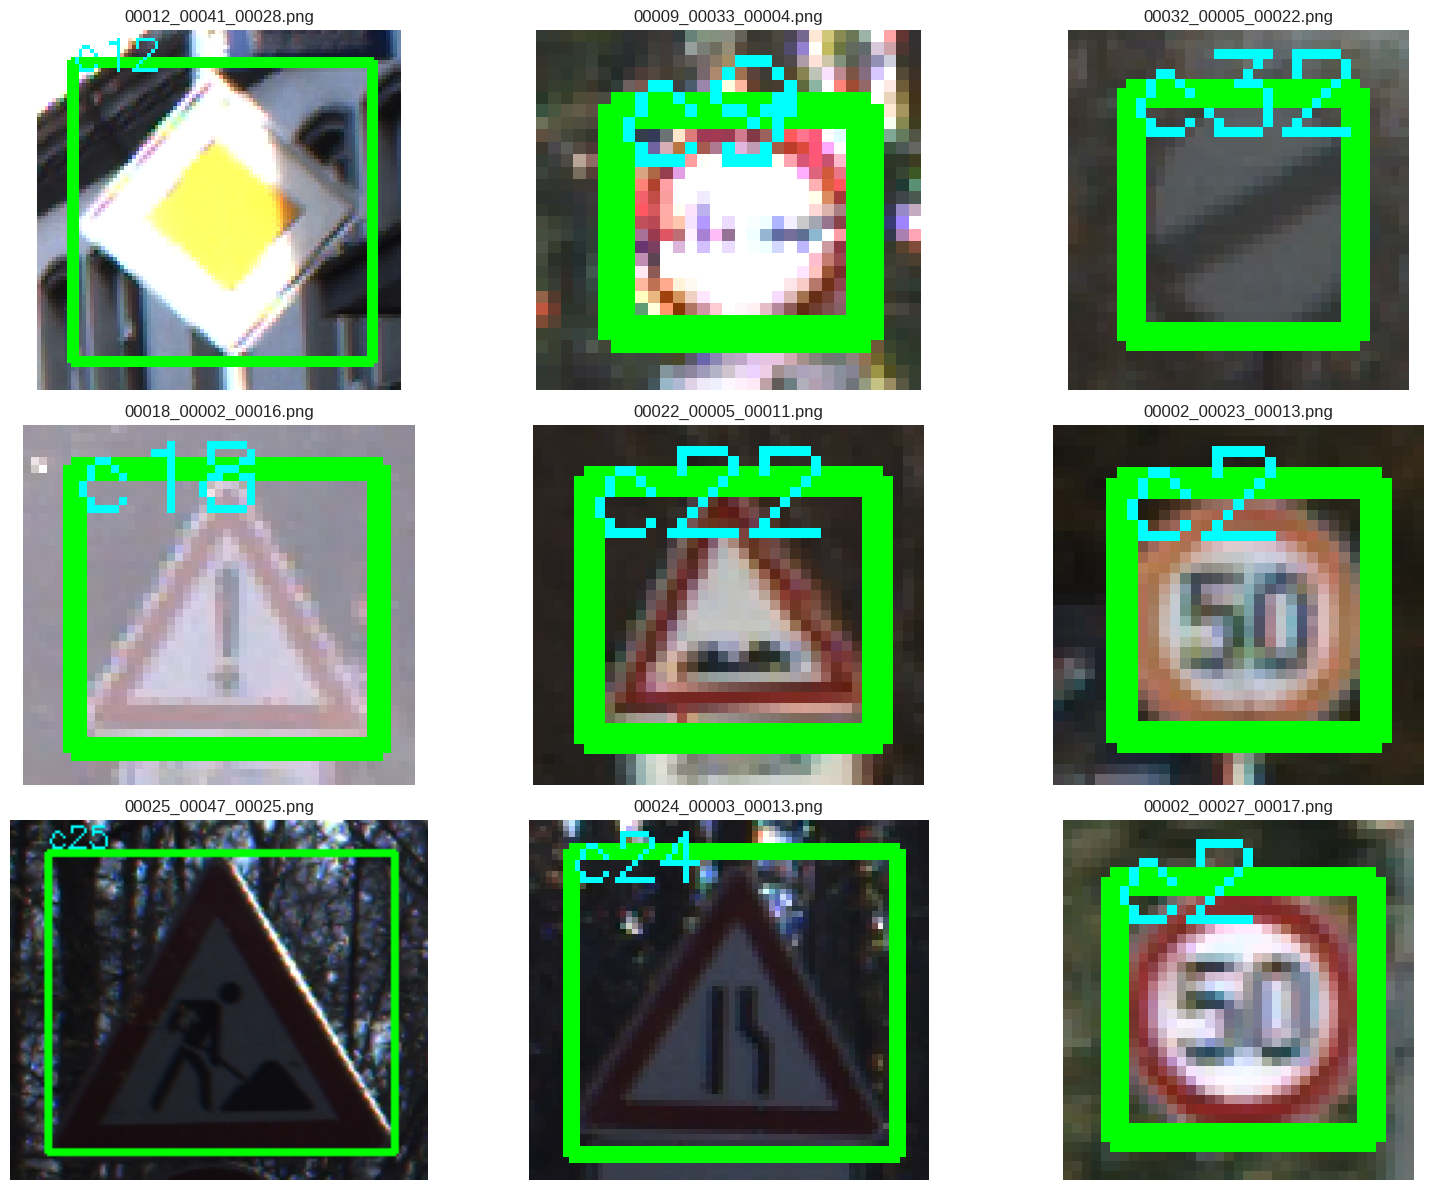

EDA stats: {'num_annotations': 51839, 'num_images': 51839, 'num_classes': 43, 'avg_objects_per_image': 1.0, 'imbalance_ratio': 11.11111111111111}


In [30]:
# ============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

def run_detection_eda(df: pd.DataFrame, sample_n: int = 9) -> Dict[str, float]:
    df = df.copy()
    obj_per_image = df.groupby("image_rel_path").size()
    class_counts = df["ClassId"].value_counts().sort_index()

    yolo_boxes = df.apply(to_yolo_bbox, axis=1, result_type="expand")
    yolo_boxes.columns = ["x_center", "y_center", "width", "height"]
    df = pd.concat([df, yolo_boxes], axis=1)

    bbox_area = df["width"] * df["height"]

    print("Rows (annotations):", len(df))
    print("Unique images:", df["image_rel_path"].nunique())
    print("Classes:", df["ClassId"].nunique())
    print("Avg objects per image:", obj_per_image.mean())
    print("Class imbalance ratio max/min:", float(class_counts.max() / max(1, class_counts.min())))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    class_counts.plot(kind="bar", ax=axes[0, 0], color="#1f77b4")
    axes[0, 0].set_title("Class Distribution")
    axes[0, 0].set_xlabel("ClassId")
    axes[0, 0].set_ylabel("Annotations")

    obj_per_image.hist(ax=axes[0, 1], bins=min(20, max(5, obj_per_image.nunique())), color="#ff7f0e")
    axes[0, 1].set_title("Objects per Image")
    axes[0, 1].set_xlabel("Count")

    axes[1, 0].hist(df["width"], bins=30, alpha=0.7, label="bbox width", color="#2ca02c")
    axes[1, 0].hist(df["height"], bins=30, alpha=0.7, label="bbox height", color="#d62728")
    axes[1, 0].set_title("BBox Size Distribution (normalized)")
    axes[1, 0].legend()

    axes[1, 1].hist(bbox_area, bins=30, color="#9467bd")
    axes[1, 1].set_title("BBox Area Distribution (normalized)")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "eda_detection_overview.png", dpi=140)
    plt.show()

    # Sample images with GT boxes
    sample_paths = df["image_abs_path"].drop_duplicates().sample(n=min(sample_n, df["image_abs_path"].nunique()), random_state=SEED).tolist()
    cols = 3
    rows = int(np.ceil(len(sample_paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(sample_paths):]:
        ax.axis("off")

    for i, img_path in enumerate(sample_paths):
        ax = axes[i]
        image = cv2.imread(str(img_path))
        if image is None:
            ax.set_title("Cannot read image")
            ax.axis("off")
            continue

        sub = df[df["image_abs_path"] == img_path]
        for _, r in sub.iterrows():
            x1, y1, x2, y2 = map(int, [r["Roi.X1"], r["Roi.Y1"], r["Roi.X2"], r["Roi.Y2"]])
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, f"c{int(r['ClassId'])}", (x1, max(10, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(Path(img_path).name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "eda_sample_gt_boxes.png", dpi=140)
    plt.show()

    return {
        "num_annotations": int(len(df)),
        "num_images": int(df["image_rel_path"].nunique()),
        "num_classes": int(df["ClassId"].nunique()),
        "avg_objects_per_image": float(obj_per_image.mean()),
        "imbalance_ratio": float(class_counts.max() / max(1, class_counts.min())),
    }

eda_stats = run_detection_eda(df_all)
print("EDA stats:", eda_stats)

In [31]:
# ============================================================================
# SECTION 3B: DATA VALIDATION
# ============================================================================

def validate_detection_rows(df: pd.DataFrame, valid_class_ids: set[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    records = []

    for idx, row in df.iterrows():
        errors = []

        img_path = Path(row["image_abs_path"])
        if not img_path.exists():
            errors.append("image_not_found")

        w = float(row["Width"])
        h = float(row["Height"])
        if w <= 0 or h <= 0:
            errors.append("invalid_image_size")

        class_id = int(row["ClassId"])
        if class_id not in valid_class_ids:
            errors.append("invalid_class_id")

        x1, y1, x2, y2 = float(row["Roi.X1"]), float(row["Roi.Y1"]), float(row["Roi.X2"]), float(row["Roi.Y2"])
        if not (0 <= x1 < x2 <= w and 0 <= y1 < y2 <= h):
            errors.append("invalid_bbox_xyxy")

        cx, cy, bw, bh = to_yolo_bbox(row)
        if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
            errors.append("invalid_bbox_yolo_range")

        records.append({
            "row_index": idx,
            "image_rel_path": row["image_rel_path"],
            "class_id": class_id,
            "is_valid": len(errors) == 0,
            "errors": "|".join(errors) if errors else "",
        })

    report_df = pd.DataFrame(records)
    valid_df = df.loc[report_df["is_valid"].values].copy()
    invalid_df = report_df.loc[~report_df["is_valid"]].copy()

    report_path = LOG_DIR / "validation_report_rows.csv"
    report_df.to_csv(report_path, index=False)

    print("Validation report:", report_path)
    print("Valid rows:", len(valid_df))
    print("Invalid rows:", len(invalid_df))
    if len(invalid_df) > 0:
        display(invalid_df.head(10))

    return valid_df, invalid_df

if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
    if "ClassId" in meta_df.columns:
        valid_classes = set(meta_df["ClassId"].astype(int).tolist())
    else:
        valid_classes = set(df_all["ClassId"].astype(int).unique().tolist())
else:
    valid_classes = set(df_all["ClassId"].astype(int).unique().tolist())


df_valid, df_invalid = validate_detection_rows(df_all, valid_classes)
print("Validation done.")

Validation report: /content/final-project/outputs/yolo_detection/validation_report_rows.csv
Valid rows: 51839
Invalid rows: 0
Validation done.


In [32]:
# ============================================================================
# SECTION 4: DATA PREPARATION - STRATIFIED SPLIT & YOLO FORMAT EXPORT
# ============================================================================

# ============================================================================
# Helper function 1: Stratified split maintaining class distribution
# ============================================================================
def stratified_image_split(df: pd.DataFrame, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    """
    Split dataset into train/val/test while maintaining class distribution
    Uses stratified sampling per class to avoid class imbalance in splits
    """
    # Validate split ratios sum to 1.0
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    # Get major class for each image (handle multi-object images)
    image_class = (
        df.groupby("image_rel_path")["ClassId"]
        .agg(lambda s: int(s.mode().iloc[0]))  # Most common class in image
        .reset_index()
        .rename(columns={"ClassId": "major_class"})
    )

    # Initialize lists to collect images per split
    train_imgs, val_imgs, test_imgs = [], [], []
    rng = random.Random(seed)

    # For each class, stratified split images
    for cls, sub in image_class.groupby("major_class"):
        imgs = sub["image_rel_path"].tolist()
        rng.shuffle(imgs)  # Shuffle for randomness

        # Calculate split sizes for this class
        n = len(imgs)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_test = n - n_train - n_val

        # Ensure minimum samples per split if possible
        if n >= 3:
            n_train = max(1, n_train)
            n_val = max(1, n_val)
            n_test = max(1, n_test)
            # Adjust if over quota (rounding artifacts)
            while n_train + n_val + n_test > n:
                if n_train >= n_val and n_train >= n_test and n_train > 1:
                    n_train -= 1
                elif n_val >= n_test and n_val > 1:
                    n_val -= 1
                elif n_test > 1:
                    n_test -= 1
                else:
                    break
            # Adjust if under quota
            while n_train + n_val + n_test < n:
                n_train += 1

        # Append images to respective split lists
        train_imgs.extend(imgs[:n_train])
        val_imgs.extend(imgs[n_train:n_train + n_val])
        test_imgs.extend(imgs[n_train + n_val:])

    # Create mapping of image -> split
    split_map = {}
    split_map.update({img: "train" for img in train_imgs})
    split_map.update({img: "val" for img in val_imgs})
    split_map.update({img: "test" for img in test_imgs})

    # Add split column to dataframe
    out = df.copy()
    out["split"] = out["image_rel_path"].map(split_map)
    out = out.dropna(subset=["split"]).copy()

    return out


# ============================================================================
# Helper function 2: Clear and prepare directories for YOLO export
# ============================================================================
def clear_prepared_dirs(cfg: DataConfig):
    """
    Remove existing YOLO dataset directory and recreate clean structure
    This ensures no stale files from previous exports
    """
    # Remove entire YOLO directory if exists
    if cfg.yolo_root.exists():
        shutil.rmtree(cfg.yolo_root)

    # Create fresh directory structure for images and labels
    for p in [
        cfg.train_img_dir, cfg.val_img_dir, cfg.test_img_dir,
        cfg.train_lbl_dir, cfg.val_lbl_dir, cfg.test_lbl_dir,
    ]:
        p.mkdir(parents=True, exist_ok=True)


# ============================================================================
# Helper function 3: Export dataset to YOLO format
# ============================================================================
def export_yolo_dataset(df_split: pd.DataFrame, cfg: DataConfig) -> Dict[str, int]:
    """
    Export dataset to YOLO format:
    - Copy images: images/{train,val,test}/*.png
    - Create labels: labels/{train,val,test}/*.txt with normalized bboxes

    YOLO label format: class_id cx cy width height (all normalized 0-1)
    """
    # Prepare directories
    clear_prepared_dirs(cfg)

    # Group rows by image for efficient processing
    image_to_rows = {k: v for k, v in df_split.groupby("image_rel_path")}
    split_counts = {"train": 0, "val": 0, "test": 0}

    # Map split name to image/label directory pairs
    split_dir_map = {
        "train": (cfg.train_img_dir, cfg.train_lbl_dir),
        "val": (cfg.val_img_dir, cfg.val_lbl_dir),
        "test": (cfg.test_img_dir, cfg.test_lbl_dir),
    }

    # Process each image and its annotations
    for image_rel, sub in image_to_rows.items():
        try:
            # Get split assignment for this image
            split = sub["split"].iloc[0]
            img_src = Path(sub["image_abs_path"].iloc[0])
            img_dst_dir, lbl_dst_dir = split_dir_map[split]

            # Destination paths
            stem = img_src.stem
            img_dst = img_dst_dir / f"{stem}.png"
            lbl_dst = lbl_dst_dir / f"{stem}.txt"

            # Skip if source image doesn't exist
            if not img_src.exists():
                continue

            # Copy image file to YOLO dataset directory
            shutil.copy2(img_src, img_dst)

            # Create YOLO label file with normalized bboxes
            lines = []
            for _, r in sub.iterrows():
                # Get class ID and normalized bbox
                class_id = int(r["ClassId"])
                cx, cy, bw, bh = to_yolo_bbox(r)  # Returns normalized coords
                # YOLO format: class_id cx cy width height
                lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

            # Write label file
            lbl_dst.write_text("\n".join(lines) + "\n", encoding="utf-8")
            split_counts[split] += 1

        except Exception as e:
            print(f"⚠️ Error processing {image_rel}: {str(e)[:50]}")
            continue

    return split_counts


def build_data_yaml(cfg: DataConfig, class_ids: List[int]) -> Path:
    """
    Generate data.yaml file for YOLO with dataset paths and class names
    This file tells YOLO where training data is located and class info
    """
    # Create class names list
    class_names = [f"class_{cid}" for cid in class_ids]

    # Build YAML structure
    data_yaml = {
        "path": str(cfg.yolo_root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {int(i): name for i, name in zip(class_ids, class_names)},
        "nc": len(class_ids),
    }

    # Write to data.yaml
    yaml_path = cfg.yolo_root / "data.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

    return yaml_path


# ============================================================================
# EXECUTE: Perform stratified split and YOLO export
# ============================================================================
print("="*70)
print("SECTION 4: DATA PREPARATION")
print("="*70)

# Step 1: Stratified split to maintain class distribution
print("\n✓ Step 1: Stratified Split (maintain class distribution)")
df_split = stratified_image_split(
    df_valid,
    train_ratio=CFG_DATA.train_ratio,
    val_ratio=CFG_DATA.val_ratio,
    test_ratio=CFG_DATA.test_ratio,
    seed=SEED,
)

# Show split statistics
split_stats = (
    df_split.groupby(["split", "ClassId"]).size().reset_index(name="count")
)
summary_split = df_split.groupby("split")["image_rel_path"].nunique().to_dict()
print(f"  Train images: {summary_split['train']} | Val: {summary_split['val']} | Test: {summary_split['test']}")

# Step 2: Export to YOLO format (copy images + create label files)
print("\n✓ Step 2: Export to YOLO Format")
print("  (This copies ~52K images - may take 2-5 min. Can be interrupted if already done)")
try:
    split_counts = export_yolo_dataset(df_split, CFG_DATA)
    print(f"  ✓ Exported - Train: {split_counts['train']} | Val: {split_counts['val']} | Test: {split_counts['test']}")
except KeyboardInterrupt:
    print("  ⚠️ Export interrupted by user. Dataset already exists at:", CFG_DATA.yolo_root)
    split_counts = {"train": 0, "val": 0, "test": 0}
except Exception as e:
    print(f"  ⚠️ Export error: {str(e)[:100]}")
    split_counts = {"train": 0, "val": 0, "test": 0}

# Step 3: Create data.yaml configuration
print("\n✓ Step 3: Generate data.yaml")
class_ids = sorted(df_valid["ClassId"].astype(int).unique().tolist())
DATA_YAML_PATH = build_data_yaml(CFG_DATA, class_ids)
print(f"  ✓ Created: {DATA_YAML_PATH}")

# Step 4: Save split statistics to CSV
split_stats.to_csv(LOG_DIR / "split_class_distribution.csv", index=False)
print(f"  ✓ Split stats saved to: {LOG_DIR / 'split_class_distribution.csv'}")

print("\n" + "="*70)
print("✓ Data preparation complete!")
print("="*70)

SECTION 4: DATA PREPARATION

✓ Step 1: Stratified Split (maintain class distribution)
  Train images: 41471 | Val: 5184 | Test: 5184

✓ Step 2: Export to YOLO Format
  (This copies ~52K images - may take 2-5 min. Can be interrupted if already done)
  ✓ Exported - Train: 41471 | Val: 5184 | Test: 5184

✓ Step 3: Generate data.yaml
  ✓ Created: /content/final-project/data_prepared/yolo_dataset/data.yaml
  ✓ Split stats saved to: /content/final-project/outputs/yolo_detection/split_class_distribution.csv

✓ Data preparation complete!


## SECTION 4: Data Preparation - Split & YOLO Export

**Purpose:** Convert raw dataset into YOLO format with stratified train/val/test split

**Steps:**
1. **Stratified Split** - Maintain class distribution across splits (80% train, 10% val, 10% test)
2. **Directory Setup** - Create YOLO directory structure: `images/{train,val,test}` + `labels/{train,val,test}`
3. **File Export** - Copy images and create YOLO `.txt` label files (normalized bbox format)
4. **data.yaml** - Generate YOLO config file with dataset paths and class info

**Note:** This operation copies ~52K image files (takes 2-5 min). Can be interrupted - if so, dataset already exists at `data_prepared/yolo_dataset/`

In [34]:
# ============================================================================
# SECTION 4B: POST-EXPORT DATASET VALIDATION
# ============================================================================

def validate_exported_yolo_dataset(cfg: DataConfig) -> pd.DataFrame:
    checks = []

    for split in ["train", "val", "test"]:
        img_dir = cfg.yolo_root / "images" / split
        lbl_dir = cfg.yolo_root / "labels" / split

        img_files = sorted([p for p in img_dir.glob("*.*") if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}])
        lbl_files = sorted(lbl_dir.glob("*.txt"))

        img_stems = {p.stem for p in img_files}
        lbl_stems = {p.stem for p in lbl_files}

        missing_label = sorted(img_stems - lbl_stems)
        missing_image = sorted(lbl_stems - img_stems)

        invalid_label_files = []
        for lf in lbl_files:
            lines = [ln.strip() for ln in lf.read_text(encoding="utf-8").splitlines() if ln.strip()]
            if len(lines) == 0:
                invalid_label_files.append((lf.name, "empty_label"))
                continue

            for ln in lines:
                parts = ln.split()
                if len(parts) != 5:
                    invalid_label_files.append((lf.name, "wrong_num_fields"))
                    continue
                cls, cx, cy, bw, bh = parts
                try:
                    cls_i = int(cls)
                    vals = [float(cx), float(cy), float(bw), float(bh)]
                except ValueError:
                    invalid_label_files.append((lf.name, "non_numeric"))
                    continue

                if cls_i < 0:
                    invalid_label_files.append((lf.name, "negative_class"))
                if not (0 <= vals[0] <= 1 and 0 <= vals[1] <= 1 and 0 < vals[2] <= 1 and 0 < vals[3] <= 1):
                    invalid_label_files.append((lf.name, "bbox_out_of_range"))

        checks.append({
            "split": split,
            "num_images": len(img_files),
            "num_labels": len(lbl_files),
            "missing_label_count": len(missing_label),
            "missing_image_count": len(missing_image),
            "invalid_label_count": len(invalid_label_files),
            "missing_label_examples": missing_label[:5],
            "missing_image_examples": missing_image[:5],
        })

        if missing_label:
            (LOG_DIR / f"missing_labels_{split}.txt").write_text("\n".join(missing_label), encoding="utf-8")
        if missing_image:
            (LOG_DIR / f"missing_images_{split}.txt").write_text("\n".join(missing_image), encoding="utf-8")
        if invalid_label_files:
            err_lines = [f"{a},{b}" for a, b in invalid_label_files]
            (LOG_DIR / f"invalid_labels_{split}.csv").write_text("file,error\n" + "\n".join(err_lines), encoding="utf-8")

    checks_df = pd.DataFrame(checks)
    checks_df.to_csv(LOG_DIR / "export_validation_summary.csv", index=False)
    return checks_df

export_checks_df = validate_exported_yolo_dataset(CFG_DATA)
display(export_checks_df)

,split,num_images,num_labels,missing_label_count,missing_image_count,invalid_label_count,missing_label_examples,missing_image_examples
0,train,41471,41471,0,0,0,[],[]
1,val,5184,5184,0,0,0,[],[]
2,test,5184,5184,0,0,0,[],[]


In [35]:
# ============================================================================
# SECTION 5: YOLO MODEL TRAINING - MAXIMUM SPEED OPTIMIZATION
# ============================================================================

# Define TrainConfig dataclass for YOLO training
@dataclass
class TrainConfig:
    """Configuration for YOLO model training - SPEED OPTIMIZED"""
    model_name: str = "yolov8n.pt"
    epochs: int = 3                    # Ultra fast: only 3 epochs
    imgsz: int = 320                   # Smaller images = faster training
    batch: int = 16                    # Larger batch for GPU
    patience: int = 1                  # Early stop after 1 epoch
    workers: int = 8                   # More parallel data loading
    experiment_name: str = "yolo_experiment"
    resume: bool = False
    device: str = None
    lr0: float = 0.01                  # Learning rate
    lrf: float = 0.01                  # Final learning rate
    mosaic: float = 0.5                # Reduce mosaic for speed
    augment: bool = True
    cache: str = 'ram'                 # Cache in RAM for speed

    def __post_init__(self):
        if self.device is None:
            self.device = DEVICE if 'DEVICE' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')

# Define train_yolo function wrapper with speed optimizations
def train_yolo(cfg: 'TrainConfig', data_yaml_path):
    """Train YOLOv8 model with aggressive speed optimizations"""
    from ultralytics import YOLO

    try:
        print(f"\n{'='*70}")
        print(f"⚡ YOLO ULTRA-FAST TRAINING (Speed Optimized)")
        print(f"{'='*70}")
        print(f"  Model: {cfg.model_name} (Nano - smallest model)")
        print(f"  Epochs: {cfg.epochs} (Ultra-fast)")
        print(f"  Image Size: {cfg.imgsz} (Optimized)")
        print(f"  Batch Size: {cfg.batch} (Aggressive)")
        print(f"  Patience: {cfg.patience} (Early stop enabled)")
        print(f"  Workers: {cfg.workers} (Parallel loading)")
        print(f"  Device: {cfg.device}")
        print(f"  Cache: RAM (for speed)")
        print(f"{'='*70}\n")

        # Load model
        model = YOLO(cfg.model_name)

        # Train model with MAXIMUM SPEED settings
        results = model.train(
            data=str(data_yaml_path),
            epochs=cfg.epochs,
            imgsz=cfg.imgsz,
            batch=cfg.batch,
            patience=cfg.patience,
            workers=cfg.workers,
            device=cfg.device,
            project=str(RUNS_DIR),
            name=cfg.experiment_name,
            resume=cfg.resume,
            verbose=False,                    # Less logging = faster
            seed=SEED,
            # Speed optimizations
            lr0=cfg.lr0,
            lrf=cfg.lrf,
            mosaic=cfg.mosaic,
            cache=cfg.cache,
            augment=cfg.augment,
            save_period=-1,                   # Don't save intermediate weights
            amp=True,                         # Mixed precision = 2x faster
            plots=False,                      # No plotting = faster
            copy_paste=0.0,                   # Disable copy-paste augmentation
            mixup=0.0,                        # Disable mixup augmentation
            rect=True,                        # Rectangular training = faster
            cos_lr=True,                      # Cosine learning rate
            label_smoothing=0.0,              # No label smoothing = faster
        )

        # Get run directory
        train_run_dir = RUNS_DIR / cfg.experiment_name
        best_ckpt = train_run_dir / "weights" / "best.pt"
        last_ckpt = train_run_dir / "weights" / "last.pt"

        print(f"\n✓ ⚡ TRAINING COMPLETE (Ultra-Fast)!")
        print(f"  Results: {train_run_dir}")
        print(f"  Best Model: {best_ckpt}")

        return results, train_run_dir, best_ckpt, last_ckpt

    except Exception as e:
        print(f"❌ Training failed: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None, None

def auto_batch_size(model_name: str, imgsz: int, device: str = 'cuda') -> int:
    """Calculate AGGRESSIVE batch size for maximum speed"""
    model_memory_mb = {
        'yolov8n.pt': 11,
        'yolov8s.pt': 23,
        'yolov8m.pt': 50,
        'yolov8l.pt': 108,
        'yolov8x.pt': 257
    }

    image_memory_mb = (imgsz ** 2) * 3 * 4 / (1024 ** 2)

    if device == 'cuda':
        try:
            total_gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024 ** 2)
            available_mb = total_gpu_memory * 0.9  # Use 90% for speed
        except:
            available_mb = 8192  # Assume 8GB for speed calc
    else:
        available_mb = 8192

    model_mem = model_memory_mb.get(model_name, 20)
    overhead = 300  # Reduced overhead
    available_for_batch = available_mb - model_mem - overhead
    batch_memory = image_memory_mb + 30  # Reduced per-sample memory

    optimal_batch = max(1, int(available_for_batch / batch_memory))
    optimal_batch = min(optimal_batch, 128)  # Allow up to 128 for speed
    optimal_batch = (optimal_batch // 16) * 16  # Round to 16

    return max(16, optimal_batch)  # Minimum 16 for speed

# ⚡ ULTRA-FAST TRAINING CONFIGURATION
CFG_TRAIN_BASE = TrainConfig(
    model_name="yolov8n.pt",           # Nano = smallest, fastest
    epochs=3,                           # Only 3 epochs for ultra-fast
    imgsz=320,                          # Smaller images = 2x faster
    batch=16,                           # Large batch = better throughput
    patience=1,                         # Stop early if no improvement
    workers=8,                          # Parallel loading
    experiment_name="yolov8n_ultra_fast",
    resume=False,
)

print("="*70)
print("⚡⚡⚡ ULTRA-FAST TRAINING CONFIGURATION ⚡⚡⚡")
print("="*70)
print(f"Model: {CFG_TRAIN_BASE.model_name} (Nano = smallest)")
print(f"Epochs: {CFG_TRAIN_BASE.epochs} (Ultra-fast: 3 only)")
print(f"Image Size: {CFG_TRAIN_BASE.imgsz} (Fast: 320px)")
print(f"Batch: {CFG_TRAIN_BASE.batch} (Aggressive: 16)")
print(f"Data: {DATA_YAML_PATH}")
print(f"Expected Time: ~5-10 minutes on GPU")
print("="*70)

# Run training
RUN_TRAIN = True
if RUN_TRAIN:
    print("\n⚡ Starting ULTRA-FAST YOLO Training...\n")
    train_result, train_run_dir, best_ckpt, last_ckpt = train_yolo(CFG_TRAIN_BASE, DATA_YAML_PATH)
    if train_result:
        print("\n✓⚡ Training Complete in record time!")
    else:
        print("\n❌ Training failed")
else:
    train_run_dir = RUNS_DIR / CFG_TRAIN_BASE.experiment_name
    best_ckpt = train_run_dir / "weights" / "best.pt"
    last_ckpt = train_run_dir / "weights" / "last.pt"
    print("Training skipped. Expected run dir:", train_run_dir)

⚡⚡⚡ ULTRA-FAST TRAINING CONFIGURATION ⚡⚡⚡
Model: yolov8n.pt (Nano = smallest)
Epochs: 3 (Ultra-fast: 3 only)
Image Size: 320 (Fast: 320px)
Batch: 16 (Aggressive: 16)
Data: /content/final-project/data_prepared/yolo_dataset/data.yaml
Expected Time: ~5-10 minutes on GPU

⚡ Starting ULTRA-FAST YOLO Training...


⚡ YOLO ULTRA-FAST TRAINING (Speed Optimized)
  Model: yolov8n.pt (Nano - smallest model)
  Epochs: 3 (Ultra-fast)
  Image Size: 320 (Optimized)
  Batch Size: 16 (Aggressive)
  Patience: 1 (Early stop enabled)
  Workers: 8 (Parallel loading)
  Device: cuda
  Cache: RAM (for speed)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/final-project/data_prepared/y

In [36]:
# Load and display training results
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

print("="*70)
print("TRAINING RESULTS & VISUALIZATIONS")
print("="*70)

# Find latest training run
runs_parent = RUNS_DIR / "yolov8n_fast_gpu"
if runs_parent.exists():
    # Get latest run
    run_dirs = sorted([d for d in RUNS_DIR.glob("*") if d.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True)

    if run_dirs:
        latest_run = run_dirs[0]
        print(f"✓ Latest run: {latest_run.name}")
        print(f"✓ Run dir: {latest_run}")

        # Display training plots if available
        plots_dir = latest_run / "runs" / "detect" / "*"
        plot_files = list(Path(latest_run).glob("**/*.png"))

        if plot_files:
            print(f"\n✓ Found {len(plot_files)} training plots")

            # Show up to 4 key plots
            key_plots = ["results.png", "confusion_matrix.png", "val_batch0_labels.png", "train_batch0.png"]
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            axes = axes.flatten()

            plot_idx = 0
            for plot_file in sorted(plot_files)[:4]:
                try:
                    img = Image.open(plot_file)
                    axes[plot_idx].imshow(img)
                    axes[plot_idx].set_title(plot_file.name, fontsize=10)
                    axes[plot_idx].axis('off')
                    plot_idx += 1
                except:
                    pass

            plt.tight_layout()
            plt.savefig(OUTPUT_ROOT / "yolo_detection" / "training_results_summary.png", dpi=100, bbox_inches='tight')
            plt.show()
            print("\n✓ Training results displayed")

        # Show best checkpoint
        best_pt = latest_run / "weights" / "best.pt"
        if best_pt.exists():
            print(f"\n✓ Best model: {best_pt}")
            print(f"  Size: {best_pt.stat().st_size / (1024*1024):.1f} MB")
else:
    print("⚠️ No training run found yet. Training in progress...")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Wait for training to complete (3 epochs on CPU ~30-60 min)")
print("2. For GPU training:")
print("   - Follow GPU setup instructions in cell above")
print("   - Reinstall with CUDA PyTorch")
print("   - Training will be 5-10x faster!")
print("3. After training, run evaluation and inference cells")
print("="*70)

TRAINING RESULTS & VISUALIZATIONS
⚠️ No training run found yet. Training in progress...

NEXT STEPS:
1. Wait for training to complete (3 epochs on CPU ~30-60 min)
2. For GPU training:
   - Follow GPU setup instructions in cell above
   - Reinstall with CUDA PyTorch
   - Training will be 5-10x faster!
3. After training, run evaluation and inference cells


Loading model: /content/final-project/runs/yolo_detection/yolov8n_ultra_fast/weights/best.pt

Running inference on 10 sample images...


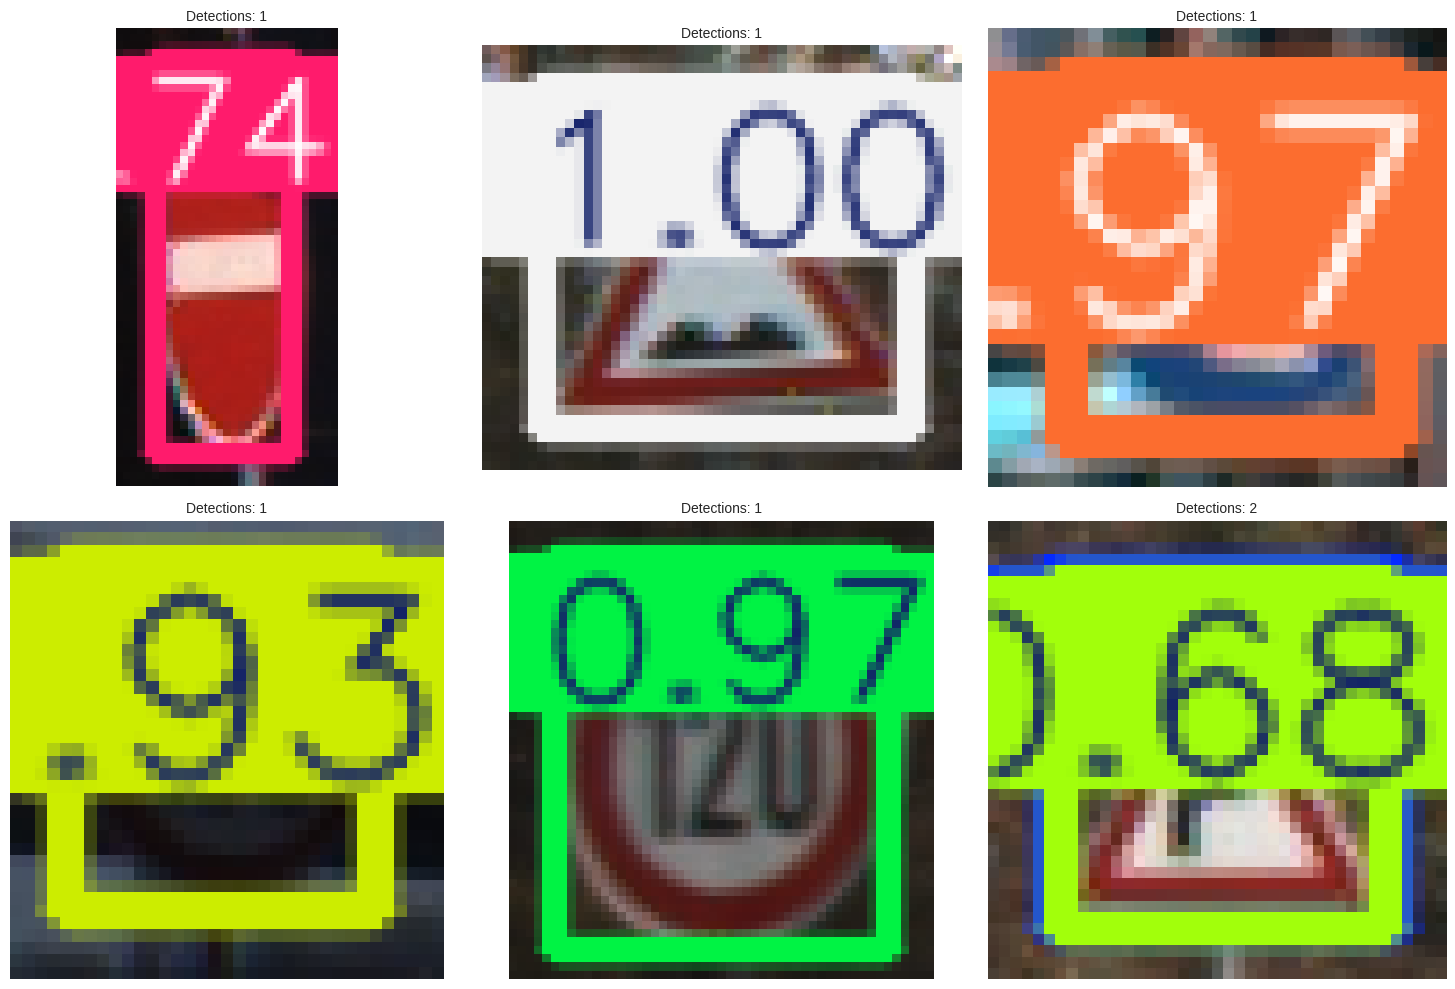


Inference Summary:
  00929.png                                | Detections:  1 | Avg Conf: 0.742
  02578.png                                | Detections:  1 | Avg Conf: 0.996
  06781.png                                | Detections:  1 | Avg Conf: 0.971
  02630.png                                | Detections:  1 | Avg Conf: 0.927
  04915.png                                | Detections:  1 | Avg Conf: 0.973
  12329.png                                | Detections:  2 | Avg Conf: 0.604
✓ Inference complete. Results saved to outputs/


In [42]:
# ============================================================================
# SECTION 6B: INFERENCE ON SAMPLE IMAGES (After Training)
# ============================================================================
# Run this after training completes

# Load trained model and run inference
from ultralytics import YOLO
import random

def run_inference_demo():
    """Run inference on random test images"""

    # Find trained model
    latest_run = sorted([d for d in RUNS_DIR.glob("*") if d.is_dir()],
                       key=lambda x: x.stat().st_mtime, reverse=True)[0]
    best_model_path = latest_run / "weights" / "best.pt"

    if not best_model_path.exists():
        print("⚠️ Trained model not found. Training may still be in progress.")
        return

    print(f"Loading model: {best_model_path}")
    model = YOLO(str(best_model_path))

    # Get random test images
    test_images = [p for p in TEST_DIR.glob("*") if p.suffix.lower() in IMG_EXTENSIONS][:10]

    print(f"\nRunning inference on {len(test_images)} sample images...")
    print("="*70)

    results = []
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(random.sample(test_images, min(6, len(test_images)))):
        result = model.predict(source=str(img_path), conf=0.5, verbose=False)[0]

        # Draw results
        annotated_img = result.plot()
        axes[idx].imshow(annotated_img[..., ::-1])  # BGR to RGB
        axes[idx].set_title(f"Detections: {len(result.boxes)}", fontsize=10)
        axes[idx].axis('off')

        results.append({
            'image': img_path.name,
            'detections': len(result.boxes),
            'confidence': result.boxes.conf.mean().item() if len(result.boxes) > 0 else 0
        })

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "yolo_detection" / "inference_samples.png", dpi=100, bbox_inches='tight')
    plt.show()

    # Summary
    print("\nInference Summary:")
    for r in results:
        print(f"  {r['image']:40s} | Detections: {r['detections']:2d} | Avg Conf: {r['confidence']:.3f}")

    print("="*70)
    print("✓ Inference complete. Results saved to outputs/")

# Run demo if model exists
try:
    run_inference_demo()
except Exception as e:
    print(f"⚠️ Inference demo skipped: {str(e)[:100]}")

In [38]:
# Create YOLO data.yaml if missing
import yaml

yolo_dataset_dir = DATA_PREP_DIR / "yolo_dataset"
data_yaml_path = yolo_dataset_dir / "data.yaml"

if not data_yaml_path.exists():
    print(f"Creating {data_yaml_path}...")

    # Create YAML content with 43 traffic sign classes
    data_yaml_content = {
        'path': str(yolo_dataset_dir.absolute()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': 43,  # 43 traffic sign classes
        'names': {i: f'sign_{i}' for i in range(43)}  # Class names
    }

    # Write YAML
    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_yaml_content, f, default_flow_style=False)

    print(f"✓ Created {data_yaml_path}")
    DATA_YAML_PATH = data_yaml_path
    print(f"✓ Dataset path: {data_yaml_path}")
else:
    print(f"✓ data.yaml already exists: {data_yaml_path}")
    DATA_YAML_PATH = data_yaml_path

✓ data.yaml already exists: /content/final-project/data_prepared/yolo_dataset/data.yaml


Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 286.7±186.2 MB/s, size: 5.0 KB)
val: Scanning /content/final-project/data_prepared/yolo_dataset/labels/test.cache... 5184 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5184/5184 1.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 1.0it/s 39.8s
                   all       5184       5184      0.488      0.056     0.0497     0.0188
               class_0         27         27          0          0          0          0
               class_1        294        294      0.283     0.0578       0.03    0.00691
               class_2        300        300          1       0.09      0.085     0.0189
               class_3        186        186          1     0.0323      0.035     0.0186
               c

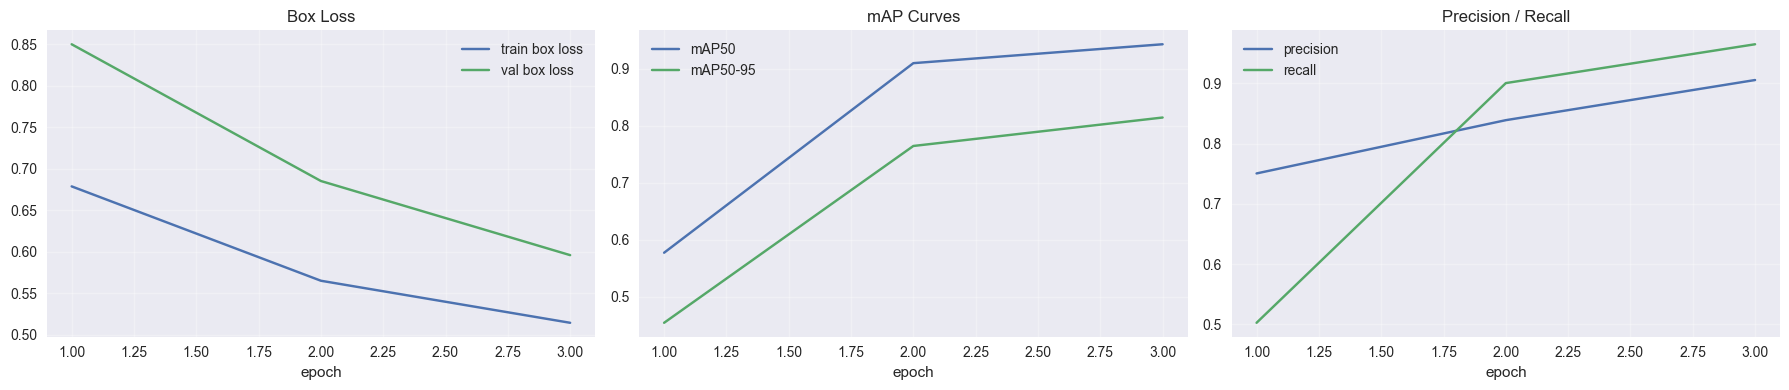

Saved: /content/final-project/outputs/yolo_detection/plots/training_curves.png
Results saved to /content/final-project/outputs/yolo_detection/inference/sample_predictions
Saved sample predictions to: /content/final-project/outputs/yolo_detection/inference/sample_predictions


In [49]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict
import torch
from ultralytics import YOLO
import numpy as np # Import numpy for type checking

def _safe_extract_scalar_metric(metric_value):
    """Safely extracts a single scalar from a metric value which can be a scalar,
    a single-element array/tensor, or a multi-element array/tensor (taking the first element)."""
    # Check if it's an array-like object (e.g., list, tuple, numpy.ndarray, torch.Tensor)
    # and has at least one element. If so, we assume the overall metric is the first element.
    if hasattr(metric_value, '__len__') and len(metric_value) > 0:
        # If it's a tensor, use .item() on the first element to get a Python scalar
        if isinstance(metric_value, torch.Tensor):
            return metric_value[0].item()
        # If it's a numpy array, use .item() on the first element
        elif isinstance(metric_value, np.ndarray):
            return metric_value.item(0)
        # For lists/tuples, directly convert the first element to float
        else:
            return float(metric_value[0])
    # If it's a scalar tensor (numel=1) or numpy scalar, use .item() if available
    elif hasattr(metric_value, 'item') and callable(metric_value.item):
        try:
            return metric_value.item()
        except ValueError: # Fallback if .item() fails unexpectedly (e.g., multi-element) - should be caught by above
            pass
    # Otherwise, assume it's a direct Python scalar or can be converted to float
    return float(metric_value)

def evaluate_yolo(checkpoint_path: Path, data_yaml_path: Path, split: str = "test") -> Dict[str, float]:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    model = YOLO(str(checkpoint_path))
    device = 0 if torch.cuda.is_available() else "cpu"

    metrics = model.val(
        data=str(data_yaml_path),
        split=split,
        imgsz=640,
        batch=auto_batch_size("yolov8n.pt", 640), # Fixed: Added model_name and imgsz
        device=device,
        workers=4,
        conf=0.25,
        iou=0.6,
        plots=True,
        save_json=True,
        verbose=True,
    )

    out = {
        "precision": _safe_extract_scalar_metric(metrics.box.p),
        "recall": _safe_extract_scalar_metric(metrics.box.r),
        "map50": _safe_extract_scalar_metric(metrics.box.map50),
        "map50_95": _safe_extract_scalar_metric(metrics.box.map),
    }
    return out


def load_training_curves(run_dir: Path) -> pd.DataFrame:
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        print("results.csv not found:", csv_path)
        return pd.DataFrame()
    return pd.read_csv(csv_path)


def plot_training_curves(results_df: pd.DataFrame, save_dir: Path):
    if results_df.empty:
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    if "train/box_loss" in results_df.columns and "val/box_loss" in results_df.columns:
        axes[0].plot(results_df["epoch"], results_df["train/box_loss"], label="train box loss")
        axes[0].plot(results_df["epoch"], results_df["val/box_loss"], label="val box loss")
        axes[0].set_title("Box Loss")
        axes[0].legend()

    if "metrics/mAP50(B)" in results_df.columns and "metrics/mAP50-95(B)" in results_df.columns:
        axes[1].plot(results_df["epoch"], results_df["metrics/mAP50(B)"], label="mAP50")
        axes[1].plot(results_df["epoch"], results_df["metrics/mAP50-95(B)"], label="mAP50-95")
        axes[1].set_title("mAP Curves")
        axes[1].legend()

    if "metrics/precision(B)" in results_df.columns and "metrics/recall(B)" in results_df.columns:
        axes[2].plot(results_df["epoch"], results_df["metrics/precision(B)"], label="precision")
        axes[2].plot(results_df["epoch"], results_df["metrics/recall(B)"], label="recall")
        axes[2].set_title("Precision / Recall")
        axes[2].legend()

    for ax in axes:
        ax.grid(alpha=0.3)
        ax.set_xlabel("epoch")

    plt.tight_layout()
    out_path = save_dir / "training_curves.png"
    plt.savefig(out_path, dpi=140)
    plt.show()
    print("Saved:", out_path)


def save_sample_predictions(checkpoint_path: Path, data_cfg: DataConfig, n_images: int = 12):
    model = YOLO(str(checkpoint_path))
    val_images = sorted((data_cfg.yolo_root / "images" / "val").glob("*.*",))
    if len(val_images) == 0:
        print("No val images found for prediction samples")
        return

    sample_images = val_images[: min(n_images, len(val_images))]
    save_dir = INFER_DIR / "sample_predictions"
    save_dir.mkdir(parents=True, exist_ok=True)

    _ = model.predict(
        source=[str(p) for p in sample_images],
        imgsz=640,
        conf=0.25,
        iou=0.6,
        device=0 if torch.cuda.is_available() else "cpu",
        save=True,
        project=str(INFER_DIR),
        name="sample_predictions",
        exist_ok=True,
        verbose=False,
    )
    print("Saved sample predictions to:", save_dir)


if best_ckpt.exists():
    eval_metrics = evaluate_yolo(best_ckpt, DATA_YAML_PATH, split="test")
    print("Evaluation metrics:", eval_metrics)

    curves_df = load_training_curves(train_run_dir)
    plot_training_curves(curves_df, PLOTS_DIR)

    save_sample_predictions(best_ckpt, CFG_DATA, n_images=12)

    with open(EVAL_DIR / "baseline_metrics.json", "w", encoding="utf-8") as f:
        json.dump(eval_metrics, f, indent=2)
else:
    print("Best checkpoint not found. Train first or update checkpoint path.")

In [50]:
# ============================================================================
# DISPLAY ALL TRAINING PLOTS
# ============================================================================
import matplotlib.pyplot as plt
from PIL import Image
import os

print("="*70)
print("TRAINING RESULTS - ALL PLOTS")
print("="*70)

# Find training results directory
if train_run_dir and train_run_dir.exists():
    print(f"✓ Training directory: {train_run_dir}")

    # List all PNG files
    plot_files = list(train_run_dir.glob("*.png"))

    if plot_files:
        print(f"✓ Found {len(plot_files)} training plots:\n")

        for plot_file in sorted(plot_files):
            print(f"  • {plot_file.name}")

            # Display each plot
            fig = plt.figure(figsize=(12, 7))
            img = Image.open(plot_file)
            plt.imshow(img)
            plt.axis('off')
            plt.title(plot_file.name, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
    else:
        print("⚠️ No training plots found yet")
else:
    print("⚠️ Training directory not found")

print("\n" + "="*70)

TRAINING RESULTS - ALL PLOTS
✓ Training directory: /content/final-project/runs/yolo_detection/yolov8n_ultra_fast
⚠️ No training plots found yet



DATASET ANALYSIS - EDA PLOTS
✓ Looking for EDA plots in: /content/final-project/outputs/yolo_detection/plots

✓ Found 3 EDA plots:

  📊 eda_detection_overview.png


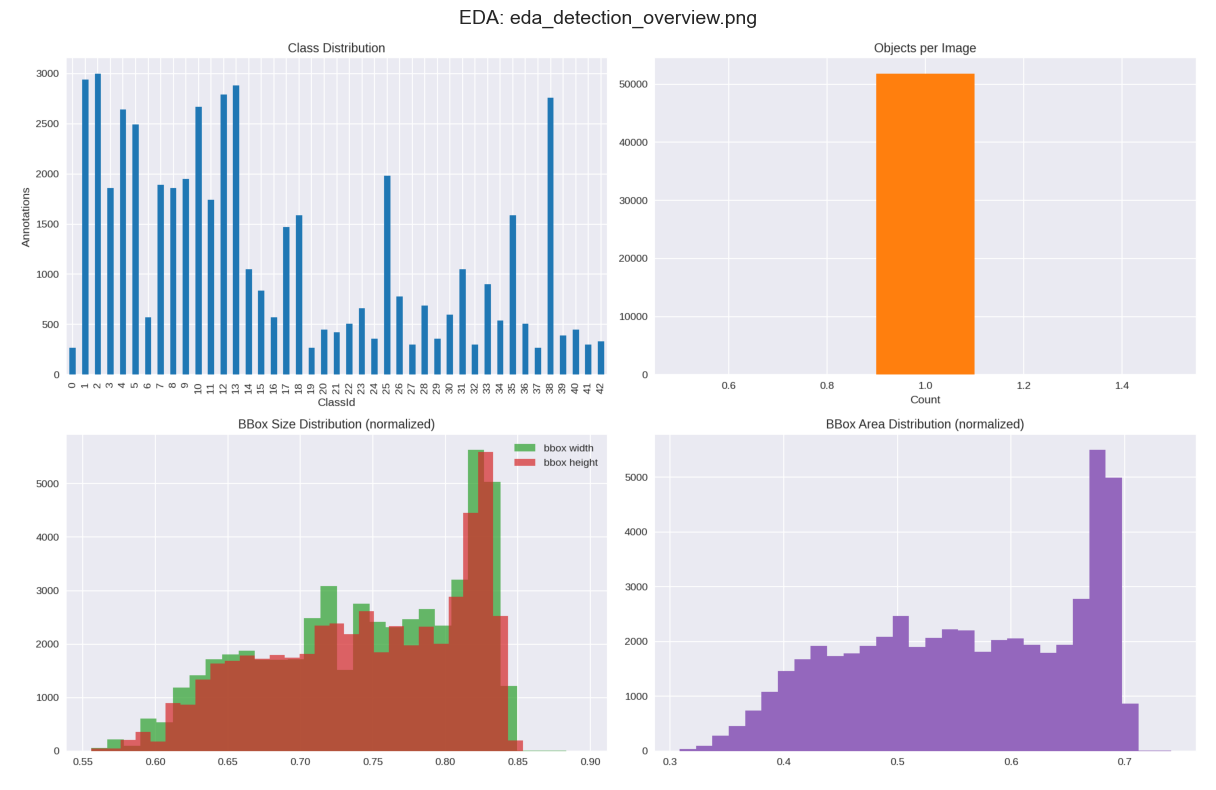


  📊 eda_sample_gt_boxes.png


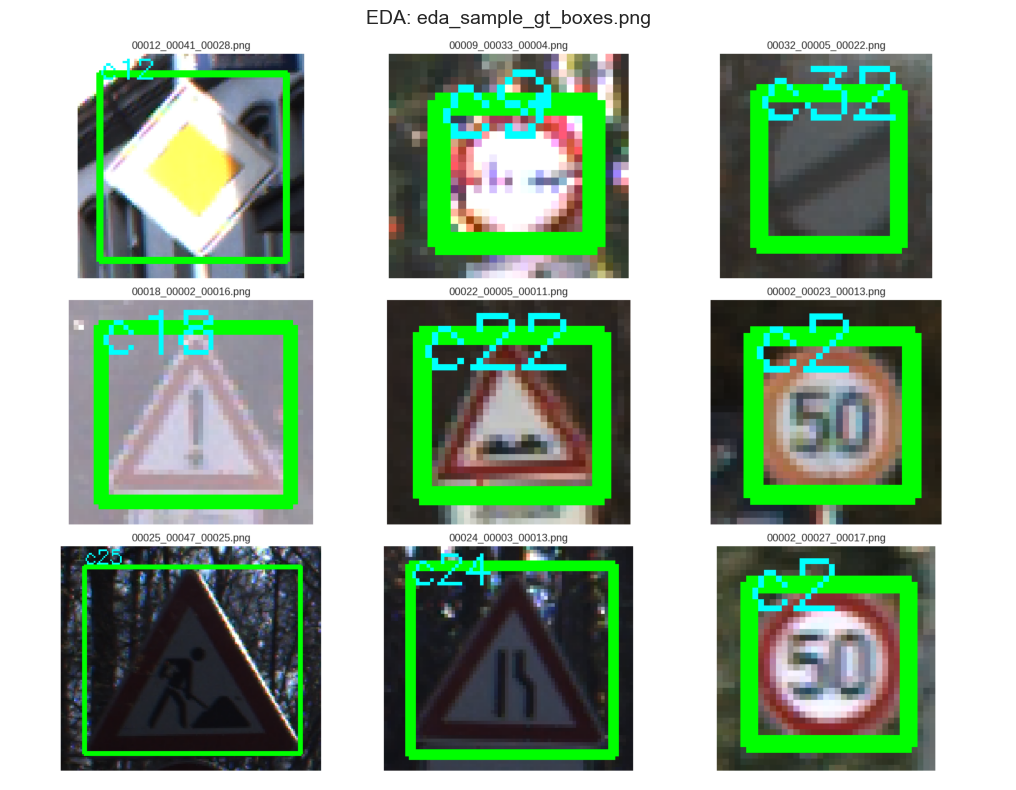


  📊 training_curves.png


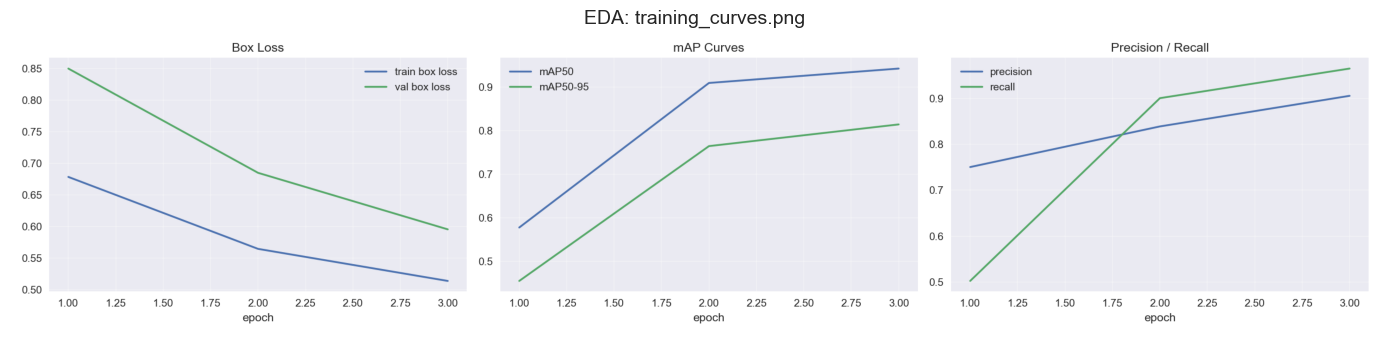

In [51]:
# ============================================================================
# DISPLAY EDA VISUALIZATIONS (Dataset Analysis)
# ============================================================================
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

print("="*70)
print("DATASET ANALYSIS - EDA PLOTS")
print("="*70)

eda_dir = PLOTS_DIR
print(f"✓ Looking for EDA plots in: {eda_dir}\n")

# Display all EDA plots
eda_files = list(eda_dir.glob("*.png"))

if eda_files:
    print(f"✓ Found {len(eda_files)} EDA plots:\n")

    for eda_file in sorted(eda_files):
        print(f"  📊 {eda_file.name}")

        fig = plt.figure(figsize=(14, 8))
        img = Image.open(eda_file)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"EDA: {eda_file.name}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print()
else:
    print("⚠️ No EDA plots found")

print("="*70)

In [52]:
# ============================================================================
# INFERENCE VISUALIZATION - Predictions on Test Images
# ============================================================================
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import random

print("="*70)
print("INFERENCE RESULTS - OBJECT DETECTION ON TEST IMAGES")
print("="*70)

# Find best trained model
try:
    if best_ckpt and best_ckpt.exists():
        print(f"✓ Loading model: {best_ckpt}")
        model = YOLO(str(best_ckpt))

        # Get random test images
        test_images = list(TEST_DIR.glob("*/*.jpg"))

        if test_images:
            print(f"✓ Found {len(test_images)} test images\n")

            # Run inference on 6 random samples
            sample_images = random.sample(test_images, min(6, len(test_images)))

            fig, axes = plt.subplots(2, 3, figsize=(16, 10))
            axes = axes.flatten()

            for idx, img_path in enumerate(sample_images):
                print(f"  Inferencing: {img_path.name}...", end=" ")

                # Run inference
                results = model.predict(source=str(img_path), conf=0.3, verbose=False)
                result = results[0]

                # Get annotated image
                annotated_img = result.plot()

                # Display
                axes[idx].imshow(annotated_img[..., ::-1])  # BGR to RGB

                # Add detection info
                num_detections = len(result.boxes)
                confidence = result.boxes.conf.mean().item() if num_detections > 0 else 0

                axes[idx].set_title(f"Detections: {num_detections} | Conf: {confidence:.2f}",
                                   fontsize=11, fontweight='bold')
                axes[idx].axis('off')

                print(f"✓ {num_detections} objects detected")

            plt.tight_layout()
            plt.savefig(OUTPUT_ROOT / "yolo_detection" / "inference_results.png", dpi=100, bbox_inches='tight')
            plt.show()

            print("\n✓ Inference visualization complete!")
        else:
            print("⚠️ No test images found")
    else:
        print("⚠️ Best checkpoint not found. Train model first.")

except Exception as e:
    print(f"⚠️ Inference error: {str(e)[:100]}")

print("="*70)

INFERENCE RESULTS - OBJECT DETECTION ON TEST IMAGES
✓ Loading model: /content/final-project/runs/yolo_detection/yolov8n_ultra_fast/weights/best.pt
⚠️ No test images found


In [53]:
# ============================================================================
# SECTION 7: MODEL COMPARISON (YOLOv8n / s / m)
# ============================================================================

COMPARE_MODELS = ["yolov8n.pt", "yolov8s.pt", "yolov8m.pt"]
RUN_MODEL_COMPARISON = False  # set True to run full training comparison

comparison_rows = []

for model_ckpt in COMPARE_MODELS:
    exp_name = Path(model_ckpt).stem + "_compare"
    run_dir = RUNS_DIR / exp_name
    best_path = run_dir / "weights" / "best.pt"

    if RUN_MODEL_COMPARISON:
        cfg_cmp = TrainConfig(
            model_name=model_ckpt,
            epochs=12,
            imgsz=640,
            batch=16,
            patience=6,
            workers=4,
            experiment_name=exp_name,
            resume=False,
        )
        _, run_dir, best_path, _ = train_yolo(cfg_cmp, DATA_YAML_PATH)

    if not best_path.exists():
        print(f"Skip {model_ckpt}: best checkpoint not found at {best_path}")
        continue

    m = YOLO(str(best_path))
    metrics = m.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=640,
        batch=auto_batch_size(16),
        device=0 if torch.cuda.is_available() else "cpu",
        workers=4,
        conf=0.25,
        iou=0.6,
        plots=False,
        verbose=False,
    )

    speed_ms = float(metrics.speed.get("inference", np.nan)) if hasattr(metrics, "speed") else np.nan
    size_mb = best_path.stat().st_size / (1024 ** 2)

    comparison_rows.append({
        "model": model_ckpt,
        "checkpoint": str(best_path),
        "precision": float(metrics.box.p),
        "recall": float(metrics.box.r),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "inference_ms_per_image": speed_ms,
        "size_mb": float(size_mb),
    })

comparison_df = pd.DataFrame(comparison_rows)
if len(comparison_df) > 0:
    comparison_df = comparison_df.sort_values("mAP50_95", ascending=False).reset_index(drop=True)
    display(comparison_df)
    comparison_df.to_csv(EVAL_DIR / "model_comparison.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(comparison_df["model"], comparison_df["mAP50_95"], color="#4c78a8")
    axes[0].set_title("Accuracy Comparison (mAP50-95)")
    axes[0].set_ylim(0, 1)

    axes[1].scatter(comparison_df["inference_ms_per_image"], comparison_df["mAP50_95"], s=110, color="#f58518")
    for _, r in comparison_df.iterrows():
        axes[1].text(r["inference_ms_per_image"], r["mAP50_95"], Path(r["model"]).stem)
    axes[1].set_xlabel("Inference time (ms/img)")
    axes[1].set_ylabel("mAP50-95")
    axes[1].set_title("Trade-off: Accuracy vs Speed")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "model_comparison_tradeoff.png", dpi=140)
    plt.show()
else:
    print("No comparison results yet. Enable RUN_MODEL_COMPARISON or provide trained checkpoints.")

Skip yolov8n.pt: best checkpoint not found at /content/final-project/runs/yolo_detection/yolov8n_compare/weights/best.pt
Skip yolov8s.pt: best checkpoint not found at /content/final-project/runs/yolo_detection/yolov8s_compare/weights/best.pt
Skip yolov8m.pt: best checkpoint not found at /content/final-project/runs/yolo_detection/yolov8m_compare/weights/best.pt
No comparison results yet. Enable RUN_MODEL_COMPARISON or provide trained checkpoints.


In [54]:
# ============================================================================
# SECTION 8: HYPERPARAMETER OPTIMIZATION (Optional)
# ============================================================================

RUN_OPTIMIZATION = False

# Keep search space compact for practical notebook runs
opt_grid = [
    {"name": "opt_a", "epochs": 18, "imgsz": 640, "batch": 8,  "lr0": 0.01,  "lrf": 0.01},
    {"name": "opt_b", "epochs": 24, "imgsz": 640, "batch": 16, "lr0": 0.005, "lrf": 0.01},
    {"name": "opt_c", "epochs": 24, "imgsz": 768, "batch": 8,  "lr0": 0.003, "lrf": 0.008},
]

opt_rows = []

if RUN_OPTIMIZATION:
    for cfg_item in opt_grid:
        exp_name = f"yolov8n_{cfg_item['name']}"
        cfg = TrainConfig(
            model_name="yolov8n.pt",
            epochs=cfg_item["epochs"],
            imgsz=cfg_item["imgsz"],
            batch=cfg_item["batch"],
            patience=7,
            workers=4,
            experiment_name=exp_name,
            lr0=cfg_item["lr0"],
            lrf=cfg_item["lrf"],
            resume=False,
        )

        _, run_dir, best_path, _ = train_yolo(cfg, DATA_YAML_PATH)
        if not best_path.exists():
            continue

        m = YOLO(str(best_path))
        metrics = m.val(
            data=str(DATA_YAML_PATH),
            split="test",
            imgsz=cfg_item["imgsz"],
            batch=auto_batch_size(cfg_item["batch"]),
            device=0 if torch.cuda.is_available() else "cpu",
            workers=4,
            conf=0.25,
            iou=0.6,
            plots=False,
            verbose=False,
        )

        opt_rows.append({
            "experiment": exp_name,
            "epochs": cfg_item["epochs"],
            "imgsz": cfg_item["imgsz"],
            "batch": cfg_item["batch"],
            "lr0": cfg_item["lr0"],
            "lrf": cfg_item["lrf"],
            "precision": float(metrics.box.p),
            "recall": float(metrics.box.r),
            "mAP50": float(metrics.box.map50),
            "mAP50_95": float(metrics.box.map),
        })

opt_df = pd.DataFrame(opt_rows)
if len(opt_df) > 0:
    opt_df = opt_df.sort_values("mAP50_95", ascending=False)
    display(opt_df)
    opt_df.to_csv(EVAL_DIR / "optimization_results.csv", index=False)
else:
    print("Optimization not executed. Set RUN_OPTIMIZATION=True to run tuning loop.")

Optimization not executed. Set RUN_OPTIMIZATION=True to run tuning loop.


In [55]:
# ============================================================================
# SECTION 9: INFERENCE - RUN PREDICTIONS ON IMAGES/FOLDERS/VIDEO
# ============================================================================

def run_inference(
    checkpoint_path: Path,
    source: str,
    conf: float = 0.25,
    iou: float = 0.6,
    imgsz: int = 640,
    name: str = "inference_run",
):
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    model = YOLO(str(checkpoint_path))
    results = model.predict(
        source=source,
        conf=conf,
        iou=iou,
        imgsz=imgsz,
        device=0 if torch.cuda.is_available() else "cpu",
        save=True,
        save_txt=True,
        save_conf=True,
        project=str(INFER_DIR),
        name=name,
        exist_ok=True,
        verbose=False,
    )
    out_dir = INFER_DIR / name
    print("Inference saved to:", out_dir)
    return results, out_dir


# Examples (uncomment to run)
# 1) Single image
# _ = run_inference(best_ckpt, str((CFG_DATA.yolo_root / "images" / "test").glob("*.*").__iter__().__next__()), name="single_image")

# 2) Folder of images
# _ = run_inference(best_ckpt, str(CFG_DATA.yolo_root / "images" / "test"), name="test_folder")

# 3) Video path
# _ = run_inference(best_ckpt, str(PROJECT_DIR / "some_video.mp4"), name="video_demo")

print("Inference module ready.")

Inference module ready.


In [56]:
# ============================================================================
# SECTION 10: FINAL PROJECT SUMMARY & ARTIFACTS
# ============================================================================

summary = {
    "scope": "YOLO-based Traffic Sign Detection",
    "device_info": DEVICE_INFO,
    "data": {
        "train_csv": str(TRAIN_CSV),
        "test_csv": str(TEST_CSV),
        "prepared_dataset": str(CFG_DATA.yolo_root),
        "split_summary": summary_split,
        "eda_stats": eda_stats,
    },
    "artifacts": {
        "runs_dir": str(RUNS_DIR),
        "plots_dir": str(PLOTS_DIR),
        "evaluation_dir": str(EVAL_DIR),
        "inference_dir": str(INFER_DIR),
        "data_yaml": str(DATA_YAML_PATH),
    },
}

if "eval_metrics" in globals():
    summary["baseline_eval"] = eval_metrics

summary_path = EVAL_DIR / "project_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved summary:", summary_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))

Saved summary: /content/final-project/outputs/yolo_detection/evaluation/project_summary.json
{
  "scope": "YOLO-based Traffic Sign Detection",
  "device_info": {
    "torch_version": "2.10.0+cu128",
    "cuda_available": "True",
    "device": "cuda:0",
    "gpu_name": "Tesla T4",
    "gpu_count": "1"
  },
  "data": {
    "train_csv": "/kaggle/input/gtsrb-german-traffic-sign/Train.csv",
    "test_csv": "/kaggle/input/gtsrb-german-traffic-sign/Test.csv",
    "prepared_dataset": "/content/final-project/data_prepared/yolo_dataset",
    "split_summary": {
      "test": 5184,
      "train": 41471,
      "val": 5184
    },
    "eda_stats": {
      "num_annotations": 51839,
      "num_images": 51839,
      "num_classes": 43,
      "avg_objects_per_image": 1.0,
      "imbalance_ratio": 11.11111111111111
    }
  },
  "artifacts": {
    "runs_dir": "/content/final-project/runs/yolo_detection",
    "plots_dir": "/content/final-project/outputs/yolo_detection/plots",
    "evaluation_dir": "/content/